# ST422 Brief 8 — Road Safety Analysis
## Week 10: Local Authority Trend Analysis

Draft — 15 March 2026

---

This notebook looks at which local authorities have seen the biggest sustained changes in KSI casualties between 2014 and 2024 — both worsening and improving. For each priority authority, it breaks down where the change is coming from: which road users, which road types, which speed environments, and whether junctions are involved.

In [1]:
%reset -f

In [2]:
# ── CONFIG ─────────────────────────────────────────────────────────────────────
CLEANED_DIR  = '/Users/zahidahmed/Documents/Stats/ST422/Data Prep/Cleaned Data'

BASE_YEARS   = [2015, 2016, 2017]   # early 3-year window (secondary robustness check)
RECENT_YEARS = [2022, 2023, 2024]   # recent 3-year window (secondary robustness check)
MIN_KSI_BASE = 30                   # min mean annual KSI to include LA
MIN_YEARS    = 6                    # min years of data required for OLS
LOW_R2       = 0.5                  # R² below this flags a non-linear/spike pattern
TOP_N        = 5                    # size of priority lists
TOP_N_LINES  = 3                    # LAs shown in trend line charts
# ──────────────────────────────────────────────────────────────────────────────

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

plt.rcParams.update({
    'figure.facecolor': 'white', 'axes.facecolor': '#f8f9fa',
    'axes.spines.top': False, 'axes.spines.right': False,
    'font.family': 'sans-serif', 'figure.dpi': 120
})

cas = pd.read_csv(
    f'{CLEANED_DIR}/cas_full.csv',
    dtype={'collision_index': str},
    low_memory=False
)

# KSI only, confirmed years, LA name present
ksi = cas[
    cas['ksi'].eq(True) &
    cas['provisional'].eq(False) &
    cas['la_name'].notna()
].copy()

print(f'KSI casualties loaded: {len(ksi):,}')
print(f'Years: {sorted(ksi["collision_year"].dropna().unique().astype(int).tolist())}')

KSI casualties loaded: 360,128
Years: [2014, 2015, 2016, 2017, 2018, 2019, 2020, 2021, 2022, 2023, 2024]


---
## 1. Data and Scope

KSI casualties are counted at the person level, not the collision level. One collision with three seriously injured people counts as three — this reflects the actual harm caused rather than just the number of incidents.

53 local authorities are excluded from the analysis because their boundaries changed during the period. The clearest example is North Yorkshire, which was reorganised in April 2023 — after that point, records that would previously have been attributed to Harrogate appear under the new authority name instead. Without removing these, Harrogate appears to have improved by 86% when in reality it simply stopped existing as a reporting unit. Only authorities with consistent data across the full comparison period are included.

In [4]:
# Completeness filter — drops LAs reorganised or renamed mid-window

def complete_las(df, years):
    return set(
        df[df['collision_year'].isin(years)]
        .groupby('la_name')['collision_year']
        .nunique()
        .pipe(lambda s: s[s == len(years)].index)
    )

complete     = complete_las(ksi, BASE_YEARS) & complete_las(ksi, RECENT_YEARS)
ksi_complete = ksi[ksi['la_name'].isin(complete)].copy()
print(f'LAs with complete data: {len(complete)}')
print(f'LAs dropped (boundary changes): {ksi["la_name"].nunique() - len(complete)}')

LAs with complete data: 339
LAs dropped (boundary changes): 53


---
## 2. Identifying Trends

Each authority's annual KSI count is modelled across the full 2014–2024 window to estimate the direction and rate of change. This uses all available years rather than comparing just two single years, which makes the findings more reliable.

Not every trend is clean. COVID caused a sharp drop in casualties in 2020–21 across almost every authority due to reduced travel. Some authorities have since spiked back above pre-pandemic levels — and for a few, like Leeds, most of the apparent worsening is concentrated in that post-COVID bounce rather than spread evenly across the decade. The analysis flags these cases separately so they are not treated the same as authorities with consistent year-on-year deterioration. A secondary comparison of early-period averages (2015–17) against recent averages (2022–24) is also run as a cross-check — both approaches agreed on the direction of change for 88% of authorities.

In [5]:
# Annual KSI count per LA
annual = (
    ksi_complete
    .groupby(['la_name', 'collision_year'])
    .size()
    .reset_index(name='KSI')
)

# OLS per LA
ols_rows = []
for la, grp in annual.groupby('la_name'):
    grp = grp.dropna(subset=['KSI', 'collision_year'])
    if len(grp) < MIN_YEARS:
        continue
    x = grp['collision_year'].values
    y = grp['KSI'].values
    slope, intercept, r, p, se = stats.linregress(x, y)
    ols_rows.append({
        'la_name'   : la,
        'slope'     : slope,
        'intercept' : intercept,
        'r_squared' : r**2,
        'p_value'   : p,
        'n_years'   : len(grp),
        'mean_ksi'  : y.mean(),
    })

ols = pd.DataFrame(ols_rows)
ols = ols[ols['mean_ksi'] >= MIN_KSI_BASE].copy()
ols['trend_shape'] = ols['r_squared'].apply(
    lambda r: 'Linear' if r >= LOW_R2 else 'Non-linear'
)

# Secondary check — 3-year averages
def window_avg(df, years):
    return (
        df[df['collision_year'].isin(years)]
        .groupby('la_name').size()
        .div(len(years)).reset_index(name='ksi_avg')
    )

base   = window_avg(ksi_complete, BASE_YEARS).rename(columns={'ksi_avg': 'base_avg'})
recent = window_avg(ksi_complete, RECENT_YEARS).rename(columns={'ksi_avg': 'recent_avg'})
avg_chg = base.merge(recent, on='la_name')
avg_chg['avg_pct_change'] = (avg_chg['recent_avg'] - avg_chg['base_avg']) / avg_chg['base_avg'] * 100
ols = ols.merge(avg_chg[['la_name', 'base_avg', 'recent_avg', 'avg_pct_change']], on='la_name', how='left')
ols['methods_agree'] = (ols['slope'] > 0) == (ols['avg_pct_change'] > 0)

print(f'LAs fitted: {len(ols)}')
print(f'Linear trends (R² >= {LOW_R2}): {(ols["r_squared"] >= LOW_R2).sum()}')
print(f'Non-linear trends: {(ols["r_squared"] < LOW_R2).sum()}')
print(f'Methods agree on direction: {ols["methods_agree"].sum()} / {len(ols)}')

LAs fitted: 323
Linear trends (R² >= 0.5): 38
Non-linear trends: 285
Methods agree on direction: 284 / 323


---
## 3. Authorities With the Steepest Worsening Trends

Bradford, Leeds, Southwark, Highland, and Lambeth show the largest increases in KSI casualties over the period. Bradford, Southwark, Highland, and Lambeth have seen consistent year-on-year rises — the trend is sustained, not concentrated in one unusual year. Leeds is different: it was broadly flat from 2014 to 2019, then spiked sharply after COVID and has not recovered to pre-pandemic levels. It is included in the priority list but treated differently — one more year of data will clarify whether that spike is settling or becoming the new normal.

The charts below show annual KSI counts for the top three, with the estimated trend line overlaid. The second chart shows all ten worst authorities ranked by rate of increase and flags which ones have consistent trends versus spike patterns.

In [16]:
worsening = (
    ols[ols['slope'] > 0]
    .sort_values('slope', ascending=False)
    .reset_index(drop=True)
)
worsening['rank'] = worsening.index + 1

top5_w       = worsening.head(TOP_N)
top5_w_names = top5_w['la_name'].tolist()
top3_w_names = top5_w_names[:TOP_N_LINES]

print('=== Top 5 worsening LAs ===')
print(top5_w[['rank', 'la_name', 'slope', 'r_squared', 'p_value',
              'trend_shape', 'avg_pct_change', 'methods_agree']].round(3).to_string(index=False))

=== Top 5 worsening LAs ===
 rank   la_name  slope  r_squared  p_value trend_shape  avg_pct_change  methods_agree
    1     Leeds 24.282      0.404    0.036  Non-linear          55.197           True
    2  Bradford 22.418      0.606    0.005      Linear          81.195           True
    3 Southwark 14.764      0.768    0.000      Linear          87.791           True
    4  Highland 14.573      0.765    0.000      Linear          95.616           True
    5   Lambeth 12.627      0.548    0.009      Linear          48.421           True


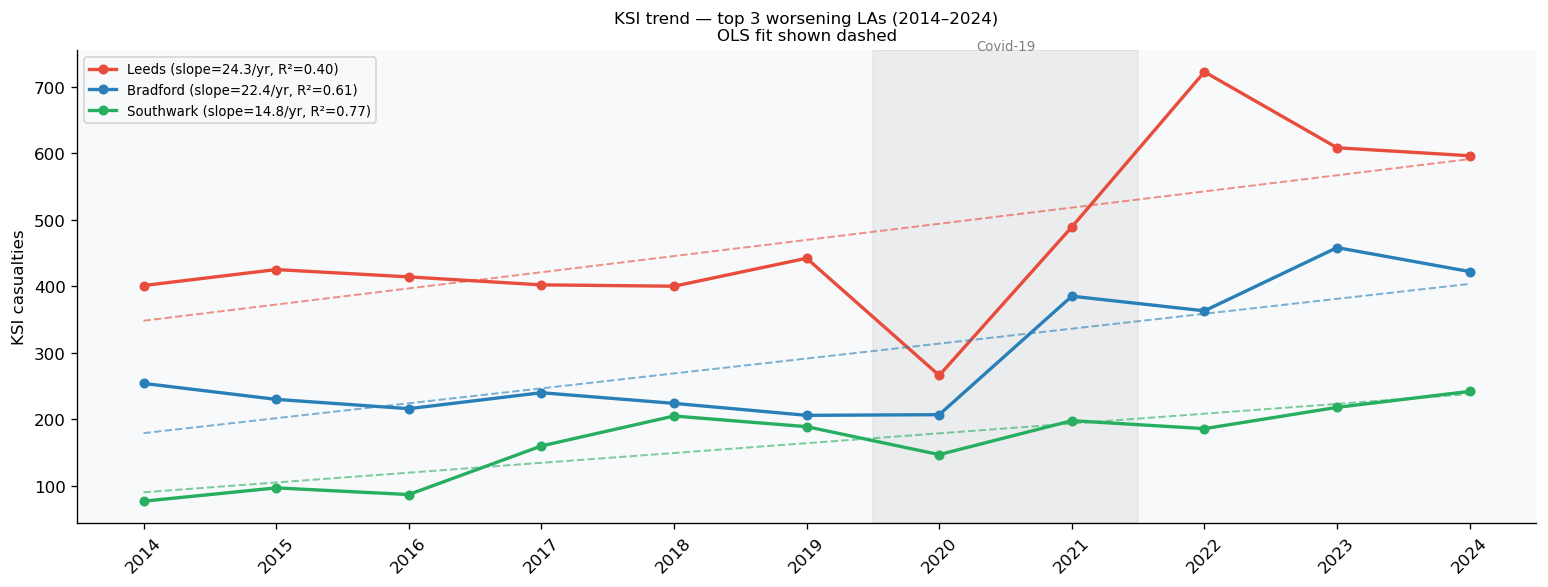

In [7]:
# Trend line chart — top 3 worsening LAs with OLS fit

annual_w    = annual[annual['la_name'].isin(top3_w_names)]
years_range = np.array(sorted(ksi_complete['collision_year'].unique()))
palette     = ['#e74c3c', '#2980b9', '#27ae60']
la_colors_w = dict(zip(top3_w_names, palette))

fig, ax = plt.subplots(figsize=(13, 5))
ax.axvspan(2019.5, 2021.5, alpha=0.10, color='grey')
ax.text(2020.5, 1, 'Covid-19', ha='center', fontsize=8,
        color='grey', transform=ax.get_xaxis_transform())

for la in top3_w_names:
    sub = annual_w[annual_w['la_name'] == la]
    row = ols[ols['la_name'] == la].iloc[0]
    c   = la_colors_w[la]
    ax.plot(sub['collision_year'], sub['KSI'], color=c, lw=2,
            marker='o', ms=5, label=f"{la} (slope={row['slope']:.1f}/yr, R²={row['r_squared']:.2f})")
    ax.plot(years_range, row['intercept'] + row['slope'] * years_range,
            color=c, lw=1.2, linestyle='--', alpha=0.6)

ax.set_title('KSI trend — top 3 worsening LAs (2014–2024)\nOLS fit shown dashed', fontsize=10)
ax.set_ylabel('KSI casualties')
ax.set_xticks(range(2014, 2025))
ax.tick_params(axis='x', rotation=45)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

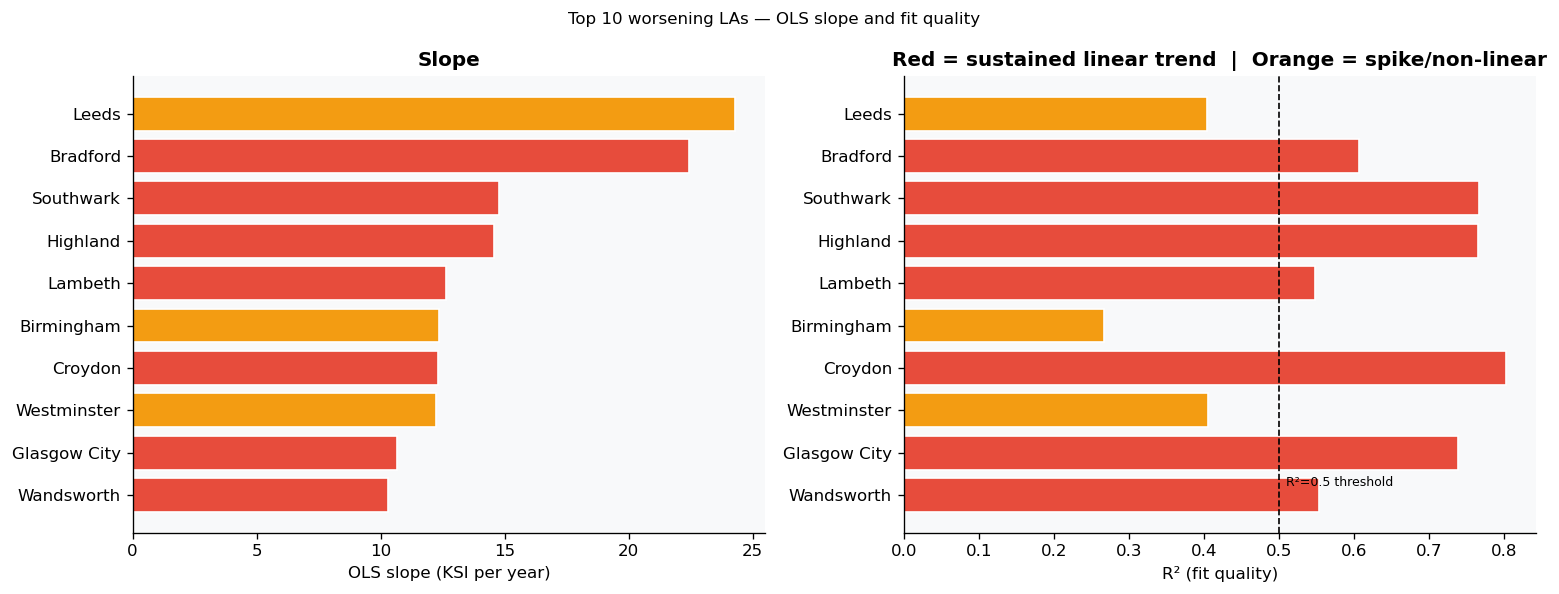

In [8]:
# Slope and R² chart — top 10 worsening LAs

top10_w = worsening.head(10)
colors_w = ['#e74c3c' if r >= LOW_R2 else '#f39c12' for r in top10_w['r_squared']]

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
axes[0].barh(top10_w['la_name'][::-1], top10_w['slope'][::-1],
             color=colors_w[::-1], edgecolor='white')
axes[0].set_xlabel('OLS slope (KSI per year)')
axes[0].set_title('Slope', fontweight='bold')

axes[1].barh(top10_w['la_name'][::-1], top10_w['r_squared'][::-1],
             color=colors_w[::-1], edgecolor='white')
axes[1].axvline(LOW_R2, color='black', lw=1, linestyle='--')
axes[1].text(LOW_R2 + 0.01, 0.2, f'R²={LOW_R2} threshold', fontsize=7.5)
axes[1].set_xlabel('R² (fit quality)')
axes[1].set_title('Red = sustained linear trend  |  Orange = spike/non-linear', fontweight='bold')

plt.suptitle('Top 10 worsening LAs — OLS slope and fit quality', fontsize=10)
plt.tight_layout()
plt.show()

### 3.1 Bradford and Leeds — Mid-Road Risk in West Yorkshire

Bradford has seen a consistent rise in KSI casualties since 2019. Looking at where those casualties are happening — the junction breakdown is telling. The large majority occur away from junctions, on open road sections. That share has not changed between the early and recent period. The implication is that the problem is not junction design — it is what is happening on open roads. Pedestrians and car occupants are both affected.

Leeds tells a different story. It was broadly stable through 2014 to 2019, then jumped sharply after the pandemic and has stayed elevated. The scale of that jump makes Leeds the highest-volume concern in West Yorkshire, but the pattern is less clear-cut than Bradford's steady rise. It is flagged for close monitoring rather than immediate structural intervention until the picture stabilises.

### 3.2 Southwark and Lambeth — Junction Risk and 20mph in South London

Both South London boroughs have seen consistent rises since before COVID. Unlike Bradford, the junction picture here is different — T and Y junction casualties are growing as a share of total KSI in both areas. That shift points toward junction design as the more relevant intervention.

Southwark also shows something worth flagging on 20mph limits. In the early period, almost all KSI casualties occurred on 30mph roads. In recent years, a substantial share are now recorded on 20mph roads — reflecting London's rollout of lower speed limits across those streets. The collisions are still happening; the roads have just been reclassified. This raises a direct question: are the new 20mph limits in Southwark being enforced? The limit change alone has not reduced casualties on those roads.

### 3.3 Highland — A Different Problem

Highland stands apart from the other four. It is almost entirely rural — single carriageway roads at 60mph — with a gradual consistent rise since 2018 that predates COVID. The road users involved are mainly car occupants and motorcyclists, with very little pedestrian or cyclist exposure. Nothing in the breakdown has shifted between the early and recent periods — the risk profile is stable and structural, not changing.

The interventions that apply to Bradford or Southwark — 20mph zones, junction redesigns, pedestrian crossings — are not relevant here. This is a rural A-road problem and needs a different response.

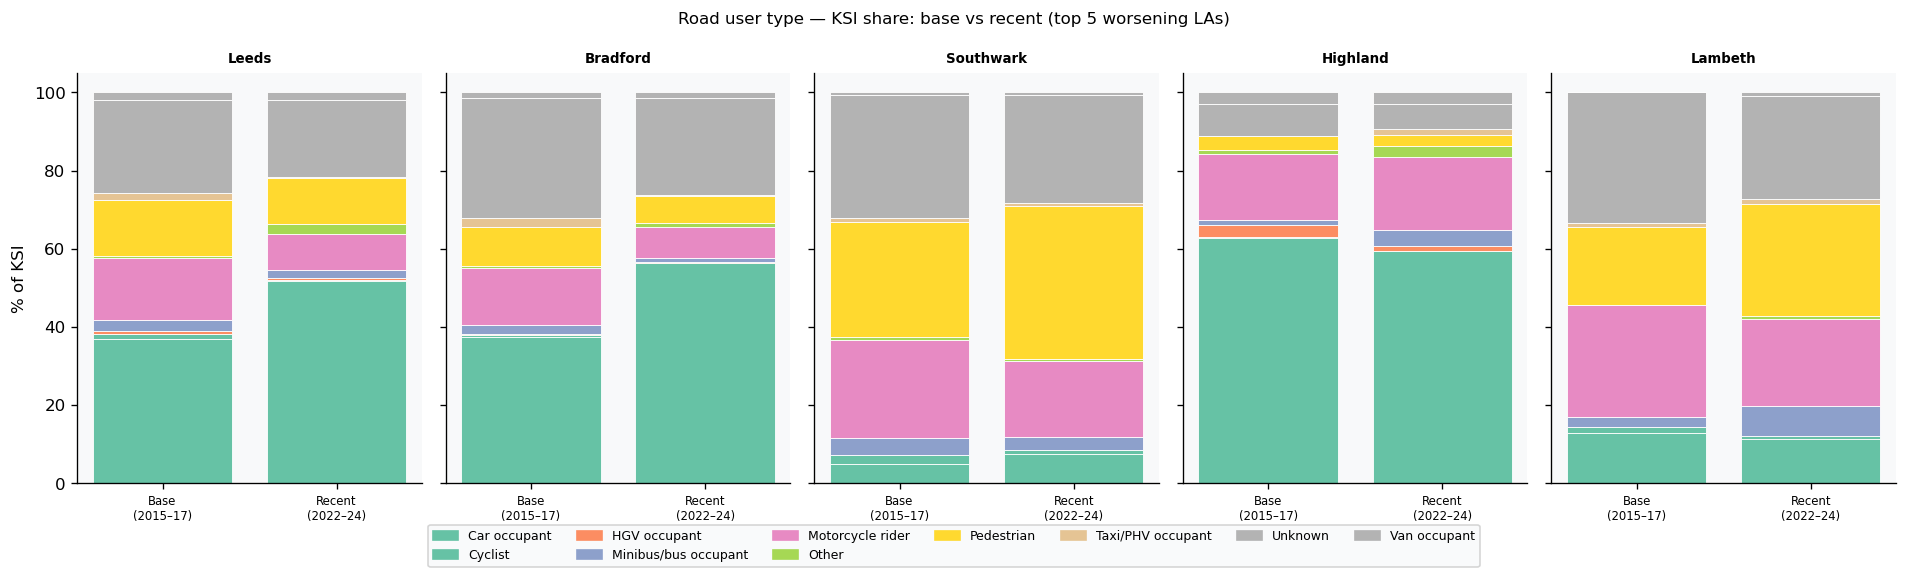

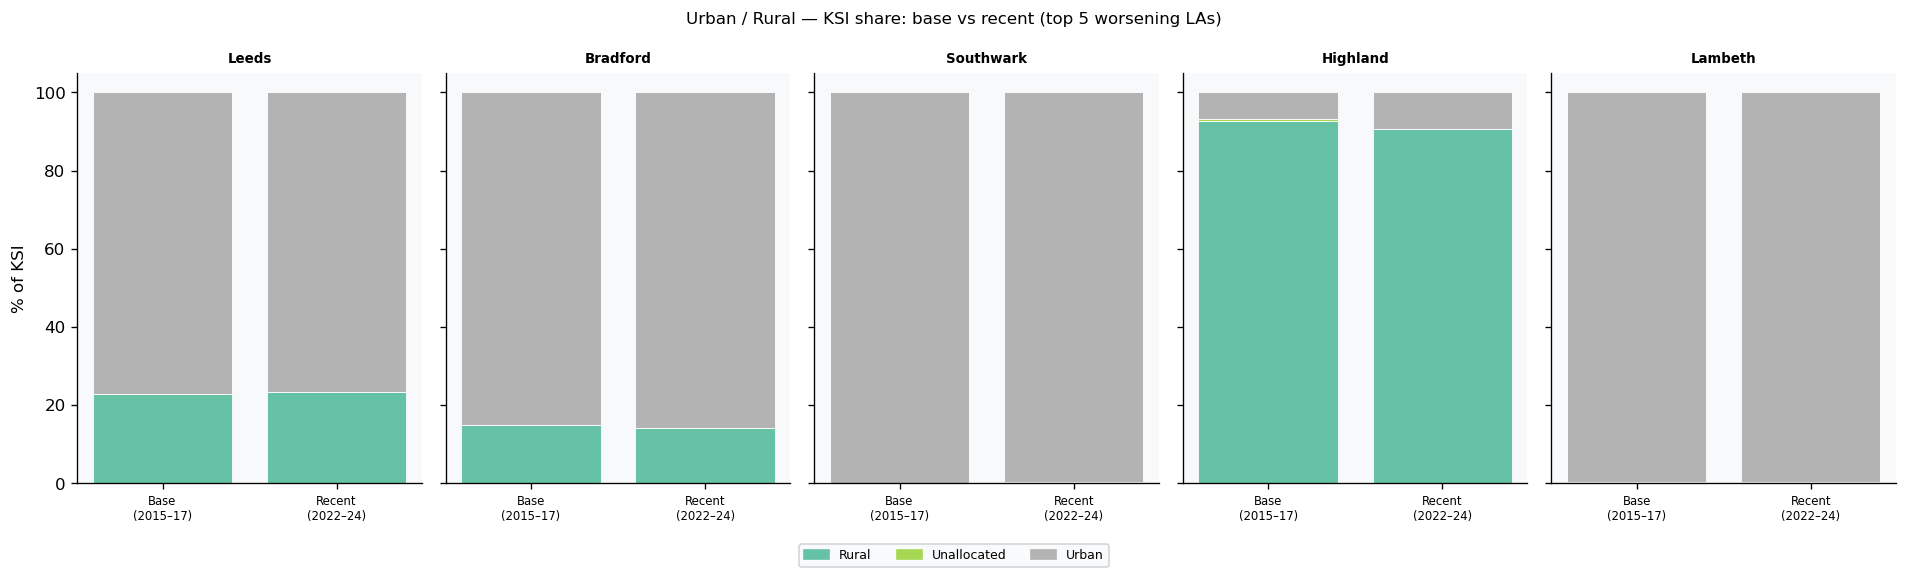

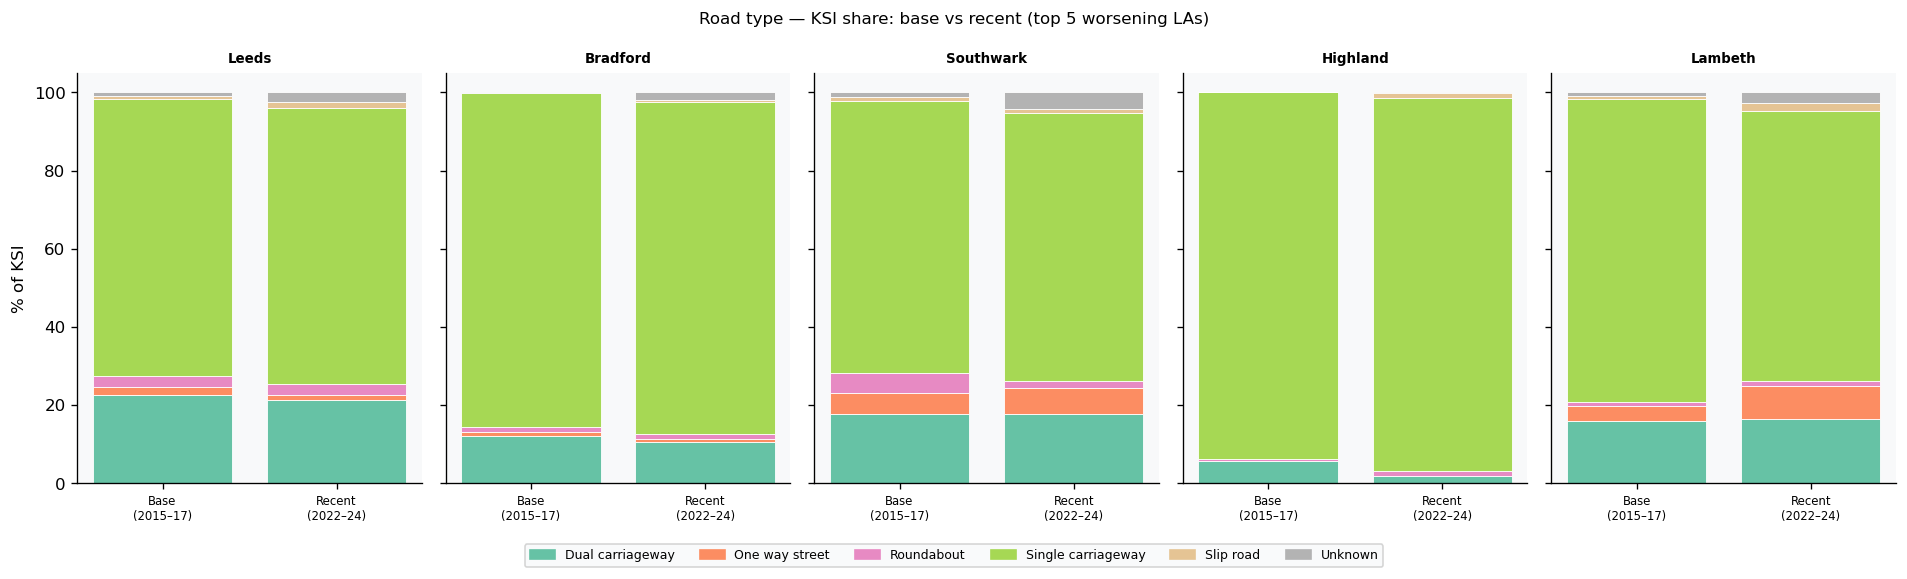

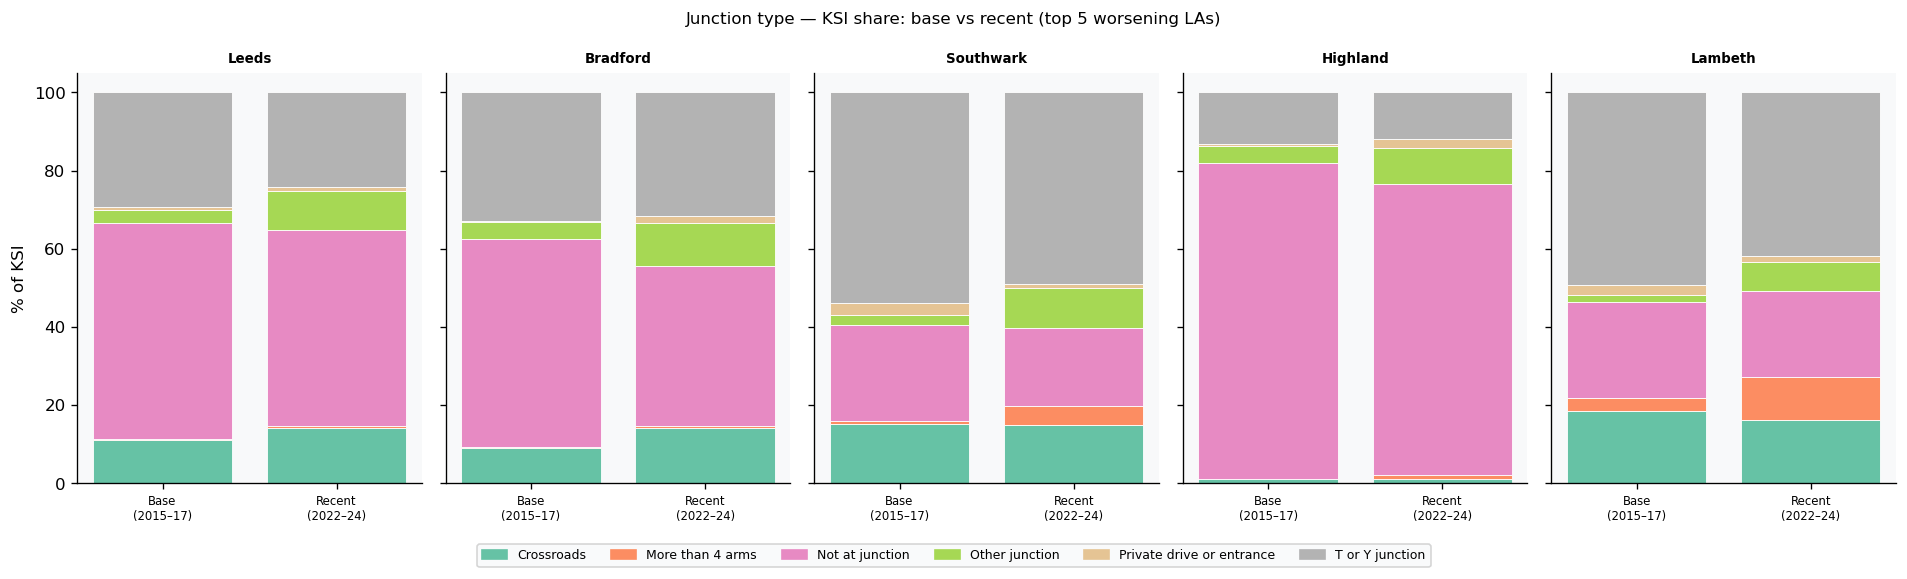

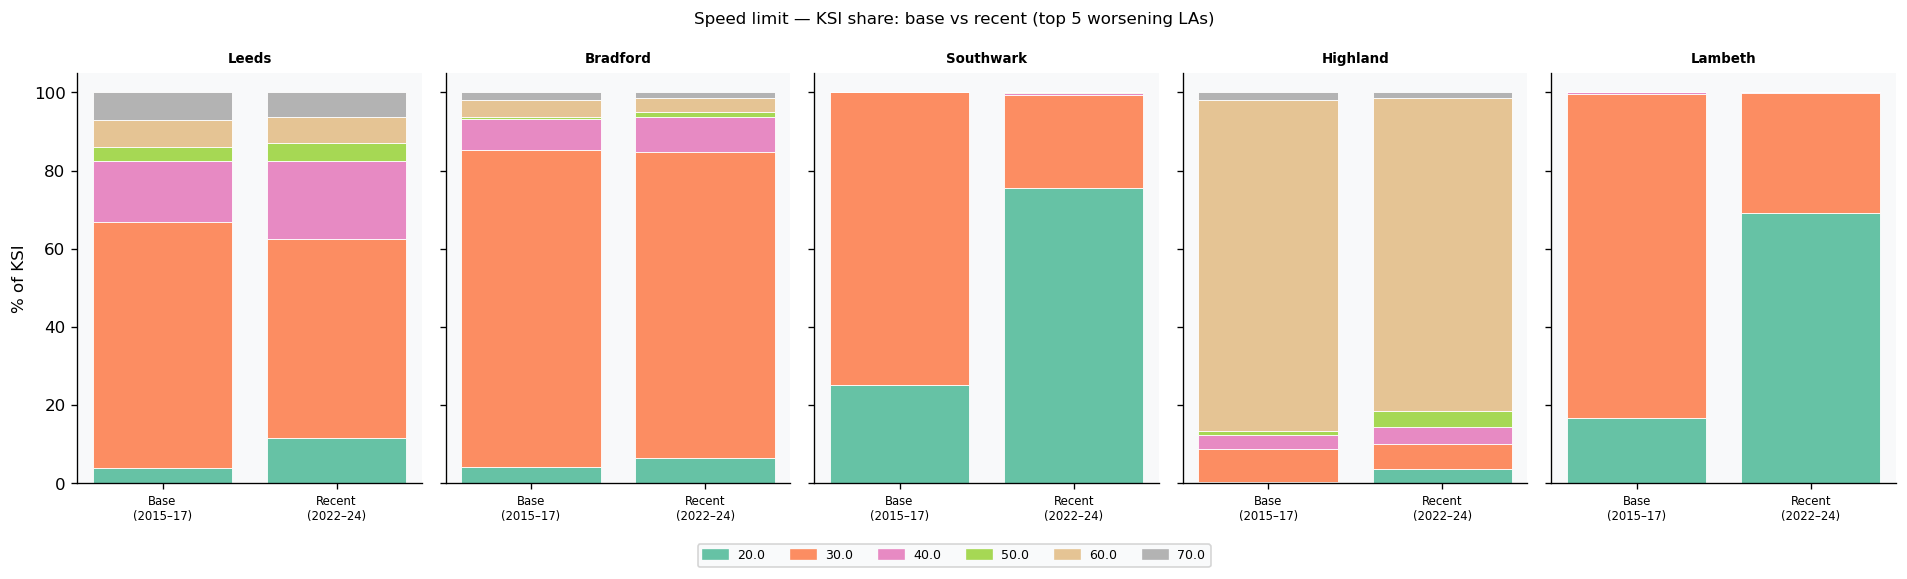

In [9]:
# Factor breakdown — KSI share base vs recent, top 5 worsening LAs

FACTORS = [
    ('road_user',       'Road user type'),
    ('ur_label',        'Urban / Rural'),
    ('road_type_label', 'Road type'),
    ('junction_label',  'Junction type'),
    ('speed_limit',     'Speed limit'),
]

deep_w = ksi_complete[
    ksi_complete['la_name'].isin(top5_w_names) &
    ksi_complete['collision_year'].isin(BASE_YEARS + RECENT_YEARS)
].copy()
deep_w['window'] = deep_w['collision_year'].apply(
    lambda y: 'Base\n(2015–17)' if y in BASE_YEARS else 'Recent\n(2022–24)'
)

for col, label in FACTORS:
    if col not in deep_w.columns:
        continue
    grp = (
        deep_w[deep_w[col].notna()]
        .groupby(['la_name', 'window', col]).size().reset_index(name='KSI')
    )
    grp['pct'] = grp.groupby(['la_name', 'window'])['KSI'].transform(lambda x: x / x.sum() * 100)
    cats = sorted(grp[col].dropna().unique().astype(str))
    cmap = plt.cm.get_cmap('Set2', len(cats))
    cat_colors = {c: cmap(i) for i, c in enumerate(cats)}
    fig, axes = plt.subplots(1, TOP_N, figsize=(16, 4.5), sharey=True)
    fig.suptitle(f'{label} — KSI share: base vs recent (top 5 worsening LAs)', fontsize=10)
    windows = ['Base\n(2015–17)', 'Recent\n(2022–24)']
    for ax, la in zip(axes, top5_w_names):
        sub     = grp[grp['la_name'] == la]
        bottoms = [0, 0]
        for cat in cats:
            vals = []
            for w in windows:
                row = sub[(sub['window'] == w) & (sub[col].astype(str) == cat)]
                vals.append(row['pct'].values[0] if not row.empty else 0)
            ax.bar(windows, vals, bottom=bottoms, color=cat_colors[cat], edgecolor='white', lw=0.5)
            bottoms = [b + v for b, v in zip(bottoms, vals)]
        ax.set_title(la, fontsize=8, fontweight='bold')
        ax.set_ylim(0, 105)
        ax.tick_params(axis='x', labelsize=7)
        if ax == axes[0]: ax.set_ylabel('% of KSI')
    handles = [plt.Rectangle((0,0),1,1, color=cat_colors[c]) for c in cats]
    fig.legend(handles, cats, loc='lower center', ncol=min(len(cats), 7),
               fontsize=7.5, bbox_to_anchor=(0.5, -0.06))
    plt.tight_layout()
    plt.show()

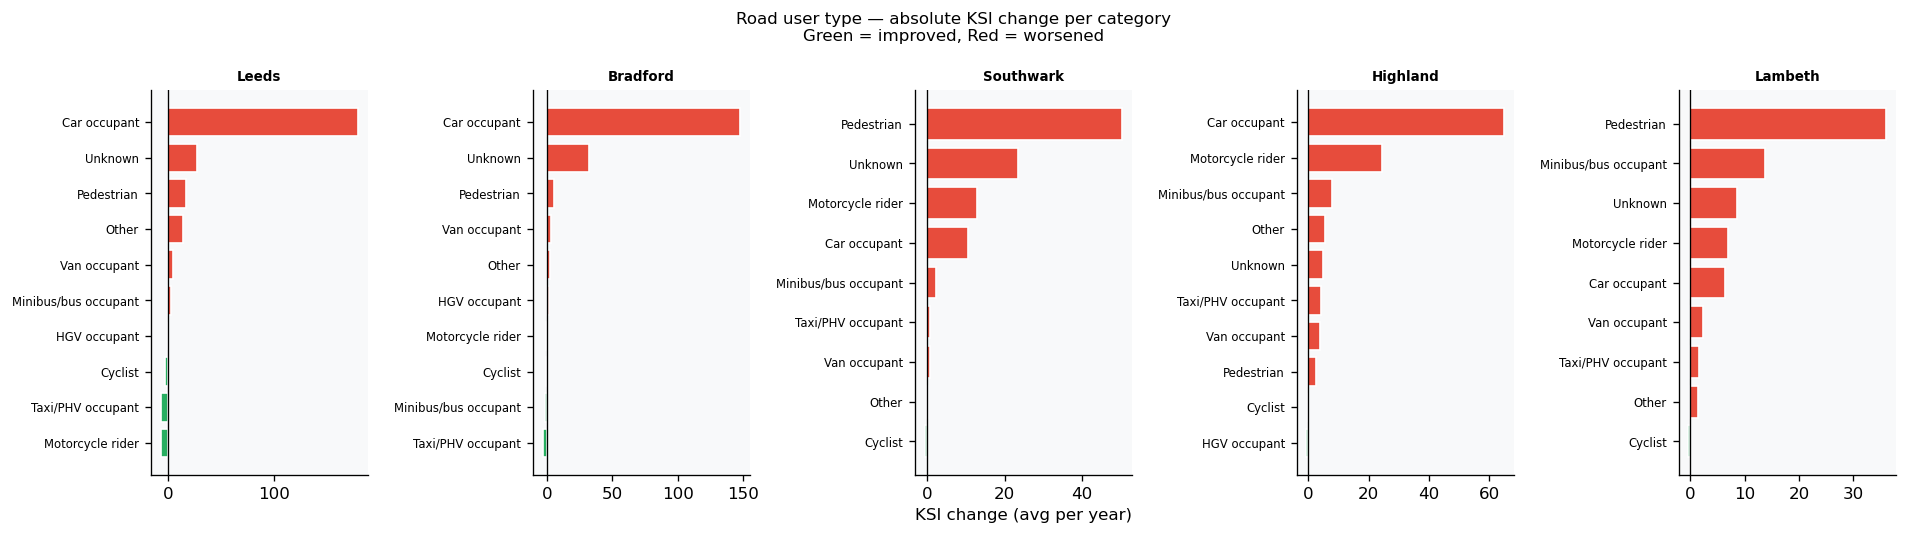

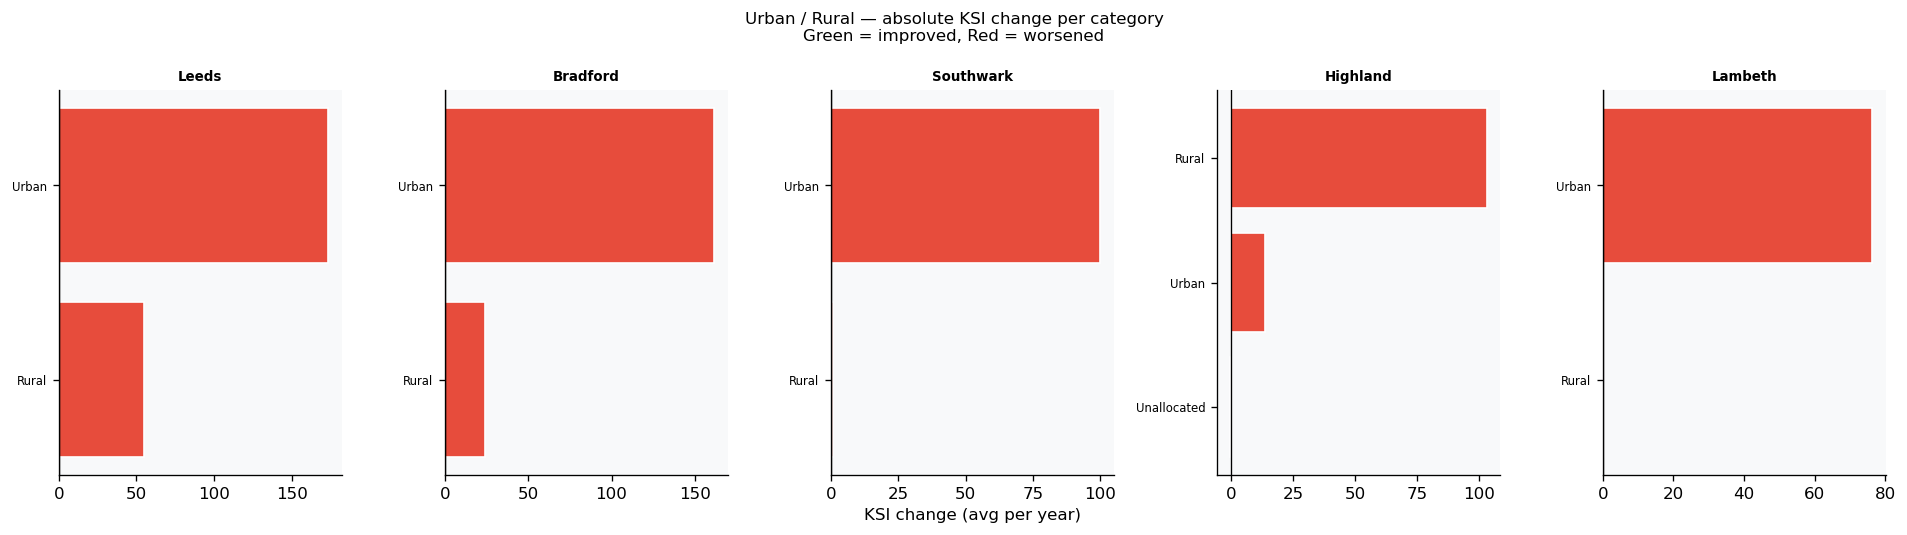

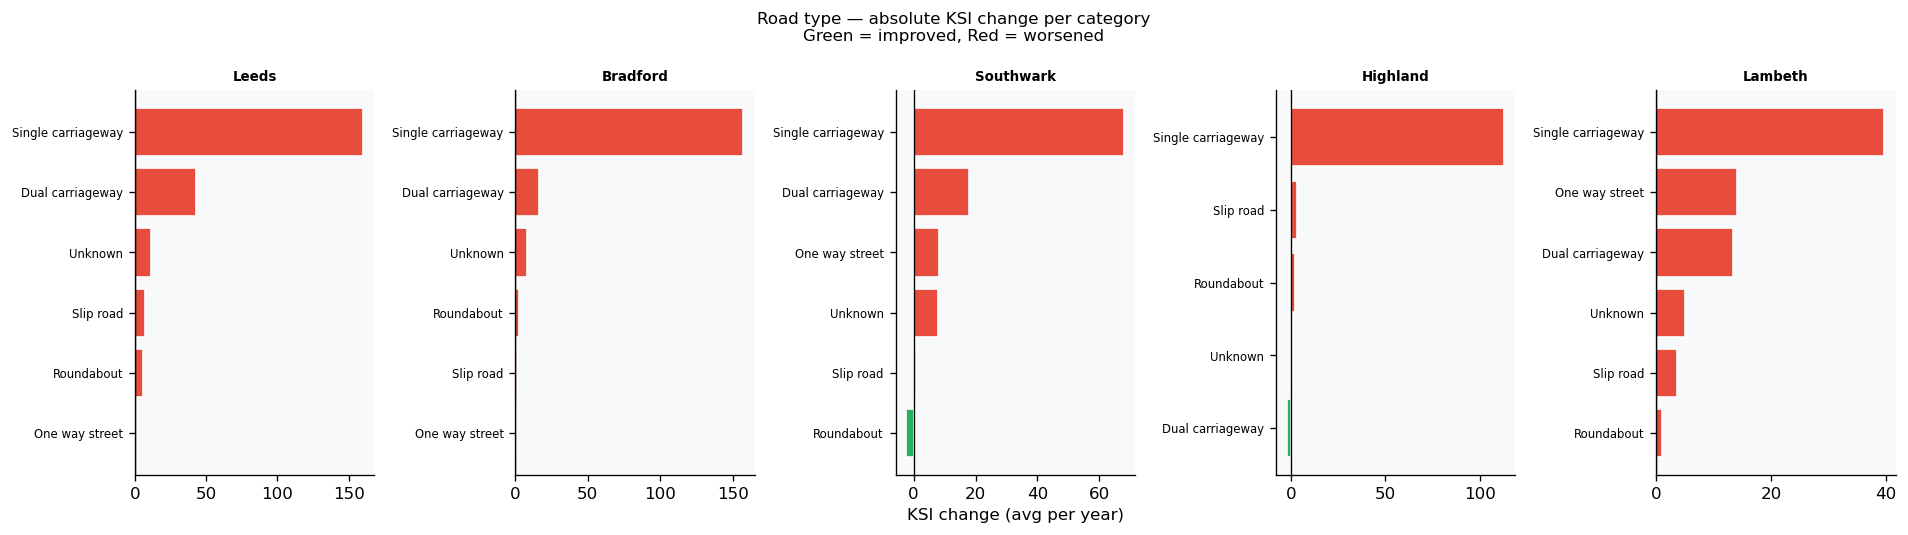

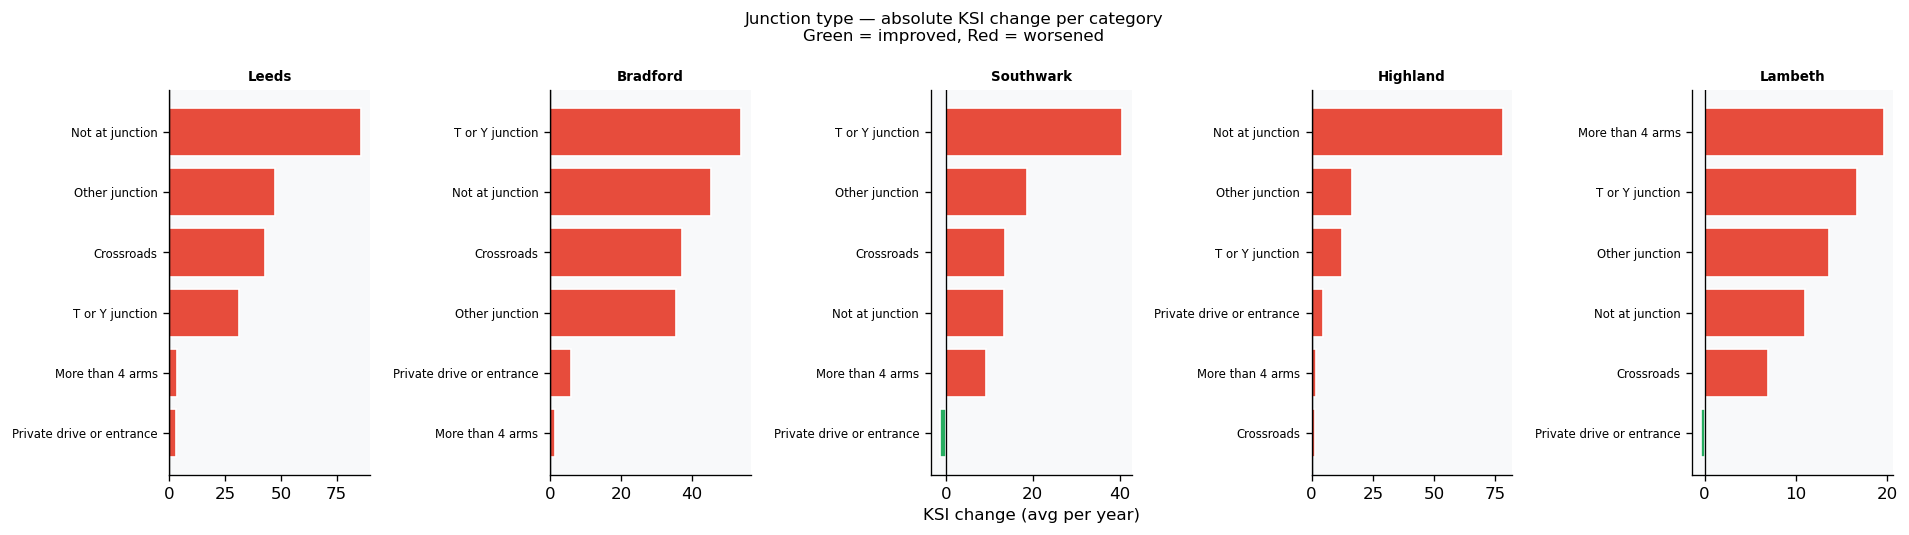

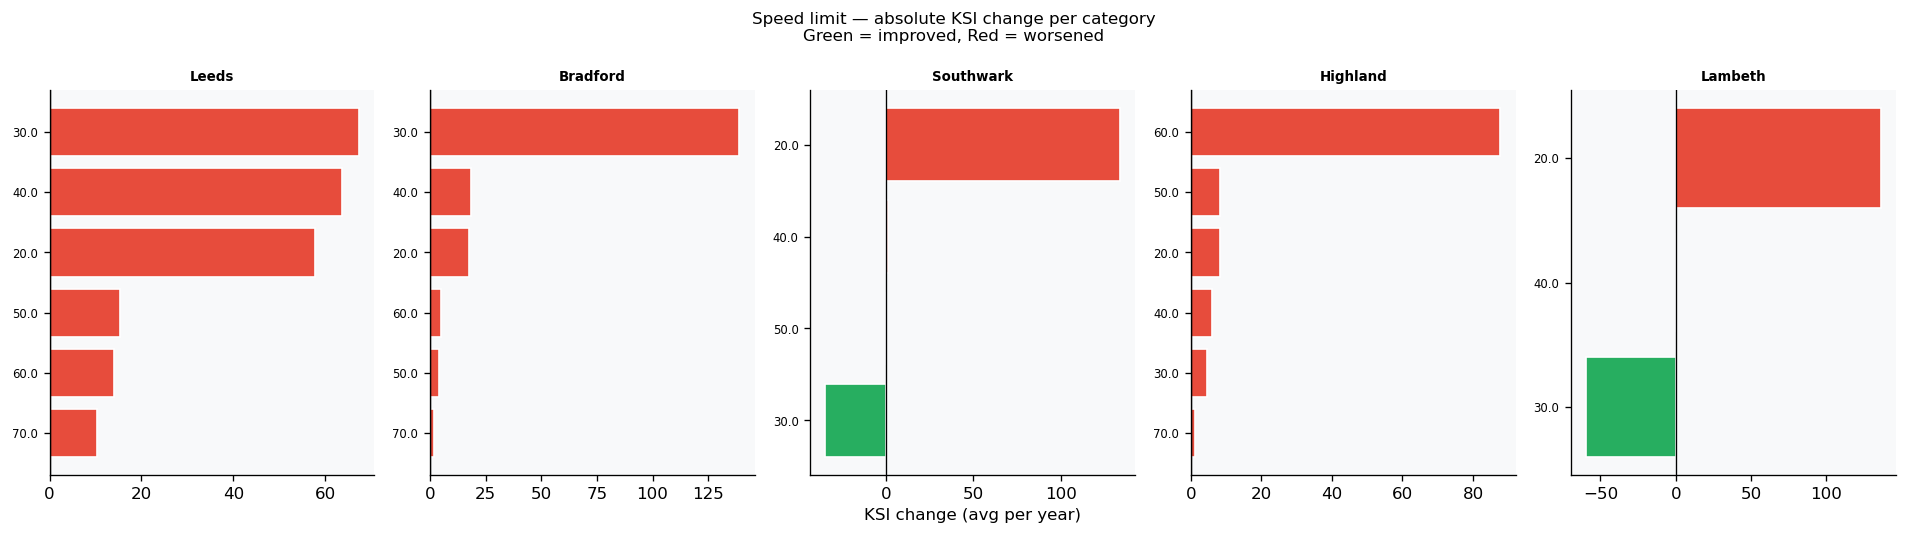

In [10]:
# Absolute KSI change per factor category — what is driving the rise?

for col, label in FACTORS:
    if col not in deep_w.columns:
        continue
    n_map = {'Base\n(2015–17)': len(BASE_YEARS), 'Recent\n(2022–24)': len(RECENT_YEARS)}
    grp = (
        deep_w[deep_w[col].notna()]
        .groupby(['la_name', 'window', col]).size().reset_index(name='ksi_count')
    )
    grp['ksi_avg'] = grp['ksi_count'] / grp['window'].map(n_map)
    pivot = grp.pivot_table(index=['la_name', col], columns='window',
                             values='ksi_avg', fill_value=0).reset_index()
    pivot.columns.name = None
    for w in ['Base\n(2015–17)', 'Recent\n(2022–24)']:
        if w not in pivot.columns: pivot[w] = 0
    pivot['rise'] = pivot['Recent\n(2022–24)'] - pivot['Base\n(2015–17)']
    fig, axes = plt.subplots(1, TOP_N, figsize=(16, 4.5), sharey=False)
    fig.suptitle(f'{label} — absolute KSI change per category\nGreen = improved, Red = worsened', fontsize=10)
    for ax, la in zip(axes, top5_w_names):
        sub    = pivot[pivot['la_name'] == la].sort_values('rise')
        colors = ['#27ae60' if v <= 0 else '#e74c3c' for v in sub['rise']]
        ax.barh(sub[col].astype(str), sub['rise'], color=colors, edgecolor='white')
        ax.axvline(0, color='black', lw=0.8)
        ax.set_title(la, fontsize=8, fontweight='bold')
        ax.tick_params(axis='y', labelsize=7)
        if ax == axes[2]: ax.set_xlabel('KSI change (avg per year)')
    plt.tight_layout()
    plt.show()

---
## 4. Authorities Showing Improvement

Liverpool, Wiltshire, Cheshire East, Cheshire West and Chester, and Milton Keynes show the largest reductions in KSI casualties over the period. Liverpool and Milton Keynes stand out — their improvements are consistent year on year, not driven by COVID. The three remaining authorities show a pattern where casualties dropped sharply during the pandemic and have not fully recovered — their improvement is real in the numbers but harder to attribute to any specific action, and they should not be treated as policy success stories on current evidence.

The contrast between Liverpool and the worsening urban authorities in Section 3 is the most useful finding in this week's analysis.

In [17]:
improving = (
    ols[ols['slope'] < 0]
    .sort_values('slope')
    .reset_index(drop=True)
)
improving['rank'] = improving.index + 1

top5_i       = improving.head(TOP_N)
top5_i_names = top5_i['la_name'].tolist()
top3_i_names = top5_i_names[:TOP_N_LINES]

print('=== Top 5 improving LAs ===')
print(top5_i[['rank', 'la_name', 'slope', 'r_squared', 'p_value',
              'trend_shape', 'avg_pct_change', 'methods_agree']].round(3).to_string(index=False))

=== Top 5 improving LAs ===
 rank                   la_name   slope  r_squared  p_value trend_shape  avg_pct_change  methods_agree
    1                 Liverpool -12.091      0.524    0.012      Linear         -23.666           True
    2                 Wiltshire  -9.655      0.277    0.096  Non-linear         -16.222           True
    3             Cheshire East  -9.582      0.432    0.028  Non-linear         -20.173           True
    4 Cheshire West and Chester  -9.227      0.490    0.017  Non-linear         -25.177           True
    5             Milton Keynes  -9.200      0.845    0.000      Linear         -42.298           True


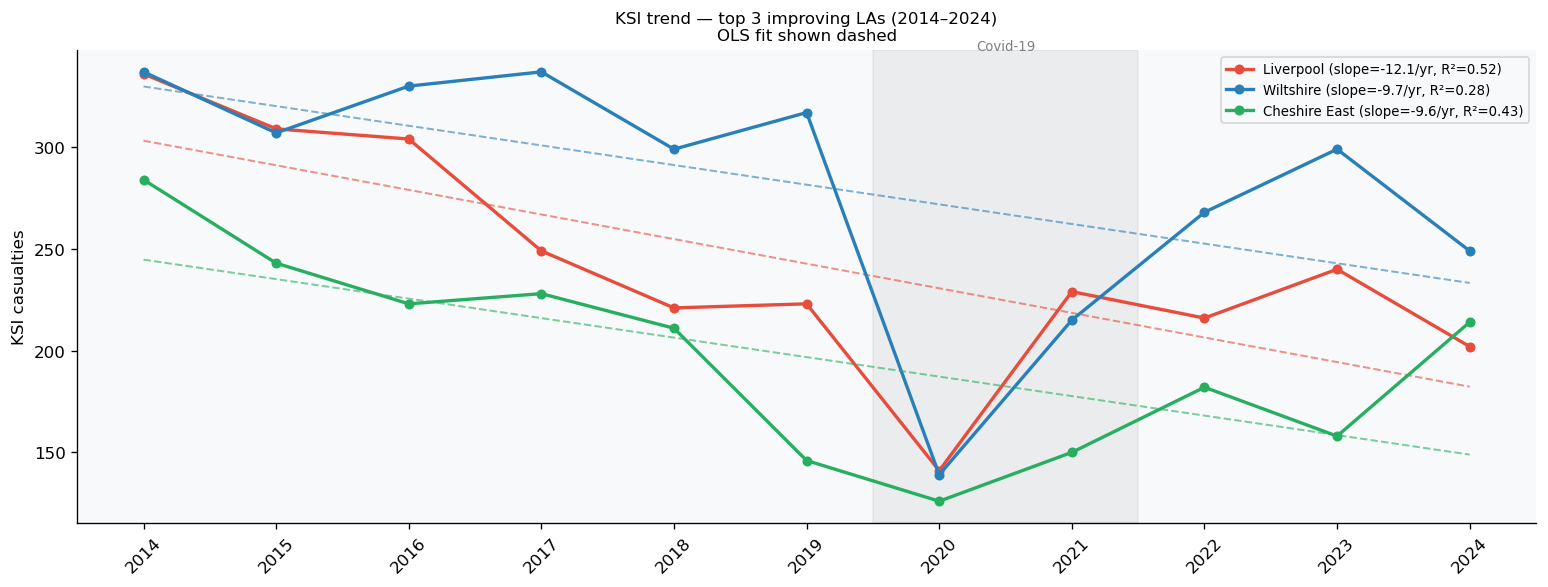

In [12]:
# Trend line chart — top 3 improving LAs with OLS fit

annual_i    = annual[annual['la_name'].isin(top3_i_names)]
la_colors_i = dict(zip(top3_i_names, palette))

fig, ax = plt.subplots(figsize=(13, 5))
ax.axvspan(2019.5, 2021.5, alpha=0.10, color='grey')
ax.text(2020.5, 1, 'Covid-19', ha='center', fontsize=8,
        color='grey', transform=ax.get_xaxis_transform())

for la in top3_i_names:
    sub = annual_i[annual_i['la_name'] == la]
    row = ols[ols['la_name'] == la].iloc[0]
    c   = la_colors_i[la]
    ax.plot(sub['collision_year'], sub['KSI'], color=c, lw=2,
            marker='o', ms=5, label=f"{la} (slope={row['slope']:.1f}/yr, R²={row['r_squared']:.2f})")
    ax.plot(years_range, row['intercept'] + row['slope'] * years_range,
            color=c, lw=1.2, linestyle='--', alpha=0.6)

ax.set_title('KSI trend — top 3 improving LAs (2014–2024)\nOLS fit shown dashed', fontsize=10)
ax.set_ylabel('KSI casualties')
ax.set_xticks(range(2014, 2025))
ax.tick_params(axis='x', rotation=45)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

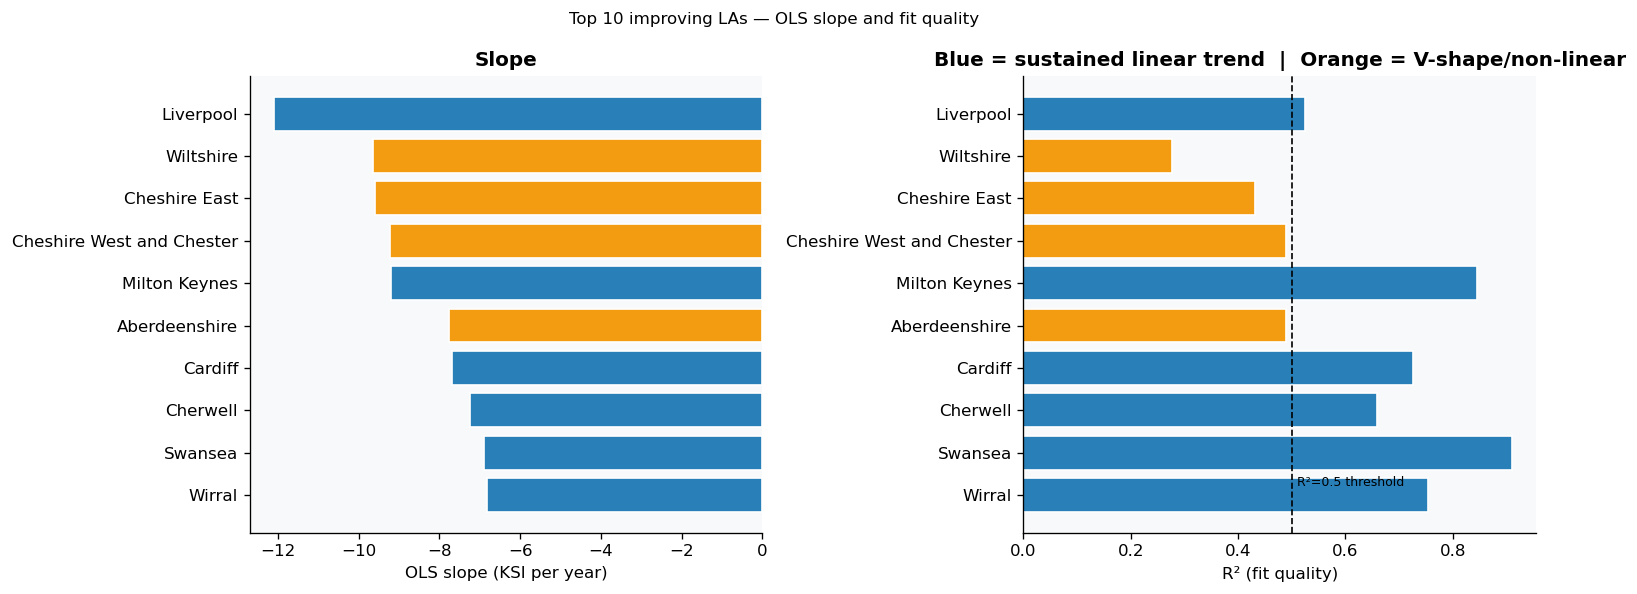

In [13]:
# Slope and R² chart — top 10 improving LAs

top10_i  = improving.head(10)
colors_i = ['#2980b9' if r >= LOW_R2 else '#f39c12' for r in top10_i['r_squared']]

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
axes[0].barh(top10_i['la_name'][::-1], top10_i['slope'][::-1],
             color=colors_i[::-1], edgecolor='white')
axes[0].set_xlabel('OLS slope (KSI per year)')
axes[0].set_title('Slope', fontweight='bold')

axes[1].barh(top10_i['la_name'][::-1], top10_i['r_squared'][::-1],
             color=colors_i[::-1], edgecolor='white')
axes[1].axvline(LOW_R2, color='black', lw=1, linestyle='--')
axes[1].text(LOW_R2 + 0.01, 0.2, f'R²={LOW_R2} threshold', fontsize=7.5)
axes[1].set_xlabel('R² (fit quality)')
axes[1].set_title('Blue = sustained linear trend  |  Orange = V-shape/non-linear', fontweight='bold')

plt.suptitle('Top 10 improving LAs — OLS slope and fit quality', fontsize=10)
plt.tight_layout()
plt.show()

### 4.1 Liverpool — Consistent Improvement Over a Decade

Liverpool has reduced KSI casualties consistently since 2014 — not a one-off dip, but a genuine sustained decline across the full window. The speed environment data is the most striking part of the picture. In the early period, almost no KSI casualties in Liverpool occurred on 20mph roads. By 2022–24, a substantial share are — and casualties are still falling. Liverpool was one of the earliest large cities to roll out 20mph zones at scale in residential areas. The data is consistent with that having made a difference, though proving cause and effect from this data alone is not possible.

This is directly relevant to Southwark, which has also introduced 20mph limits but is not seeing the same result. The difference is likely in how the policy was implemented and enforced, not in the policy itself.

### 4.2 Milton Keynes — Broad Improvement Across the Network

Milton Keynes shows the most consistent improvement of any authority in the dataset — casualties have fallen steadily across the full window. Unlike Liverpool, there is no single visible driver. The reduction is spread across road user types and speed environments, which suggests network-wide improvements rather than one targeted intervention. Dual carriageway casualties in particular have fallen, which fits the Milton Keynes grid road network. It is a useful reference point for authorities looking for broad rather than targeted improvement.

### 4.3 Wiltshire, Cheshire East, Cheshire West — COVID-Influenced, Treat With Caution

All three show a pattern where casualties fell sharply during the pandemic and have not bounced back to the same degree as elsewhere. They are all predominantly rural authorities with high-speed road exposure. The improvement in the numbers is real but its sustainability is not yet clear — it may reflect lower traffic volumes persisting post-pandemic rather than any specific road safety action. These three are worth monitoring alongside Highland, as rural authorities trending in opposite directions over the same period.

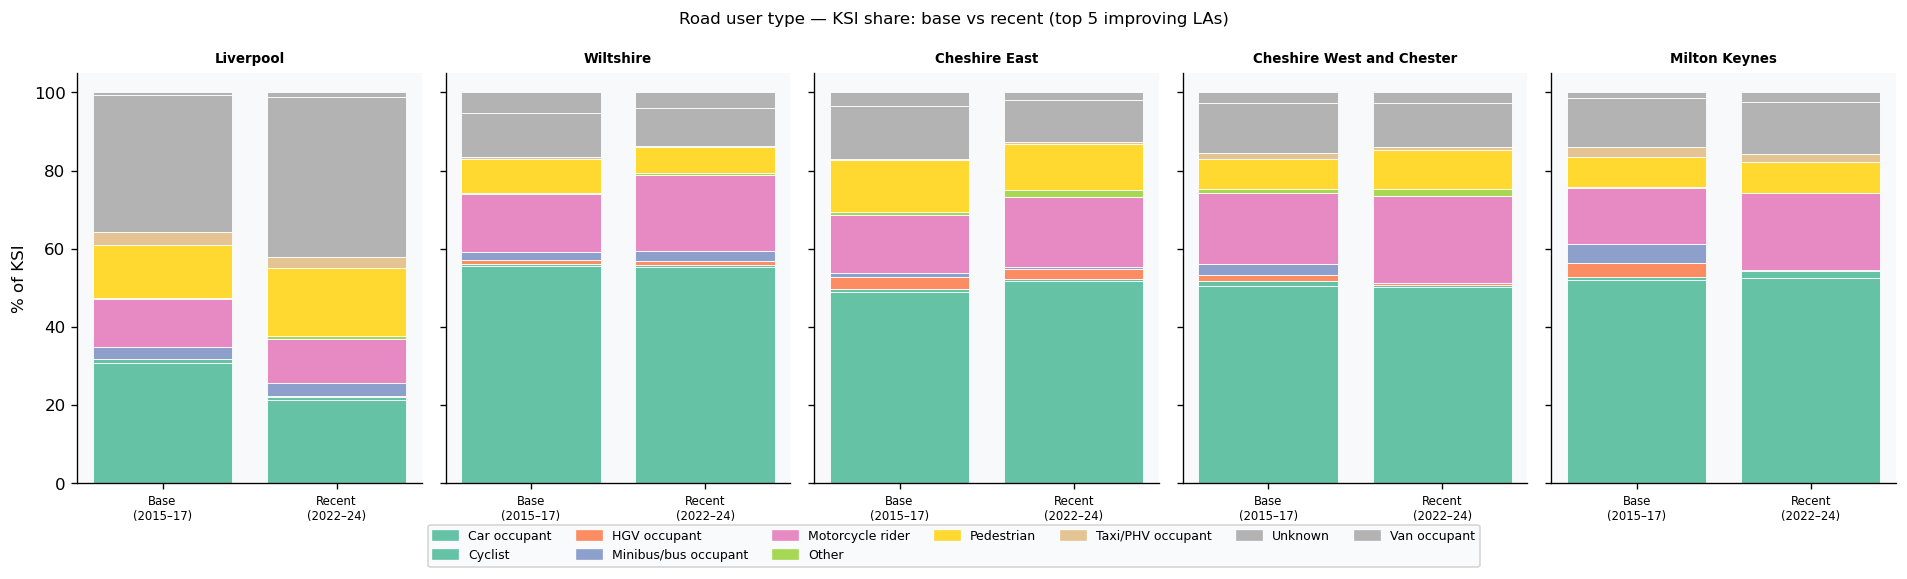

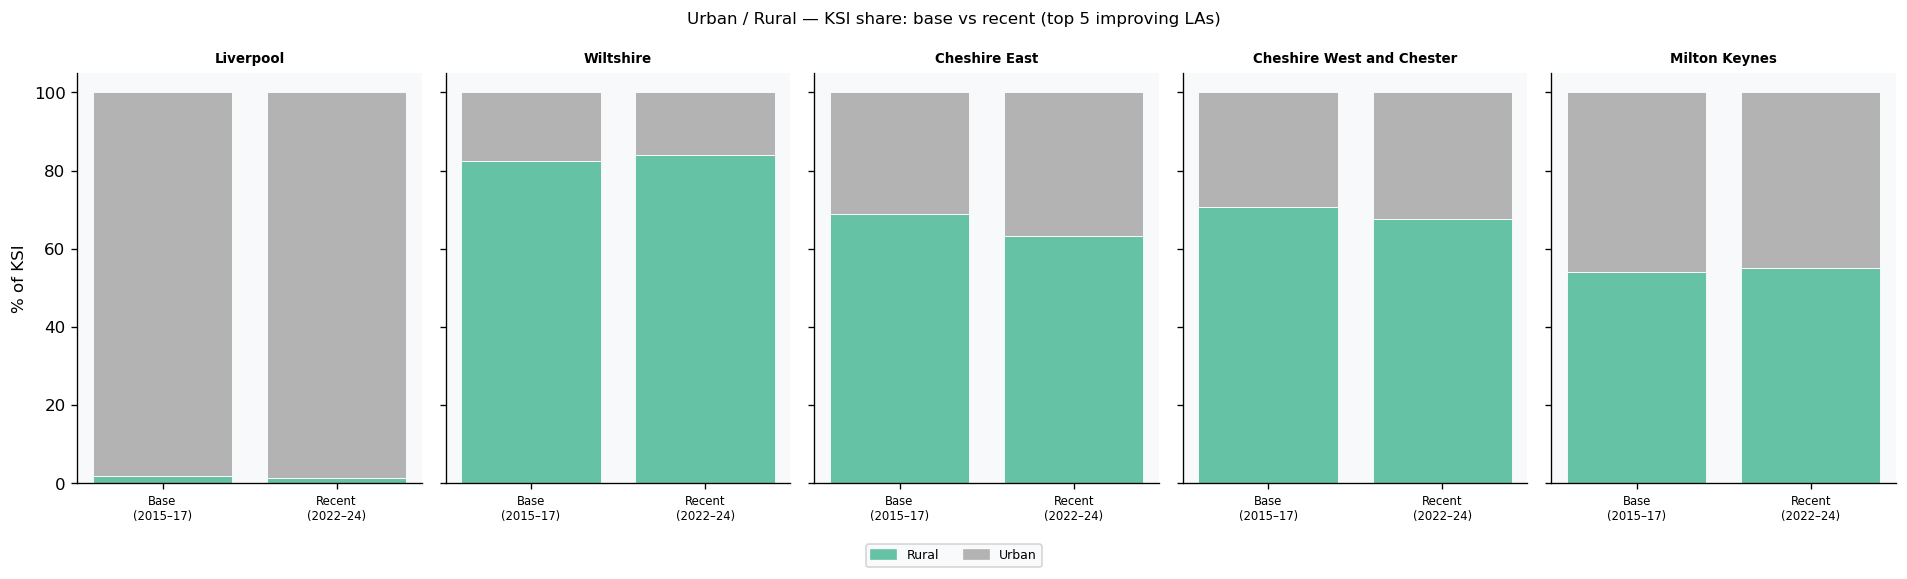

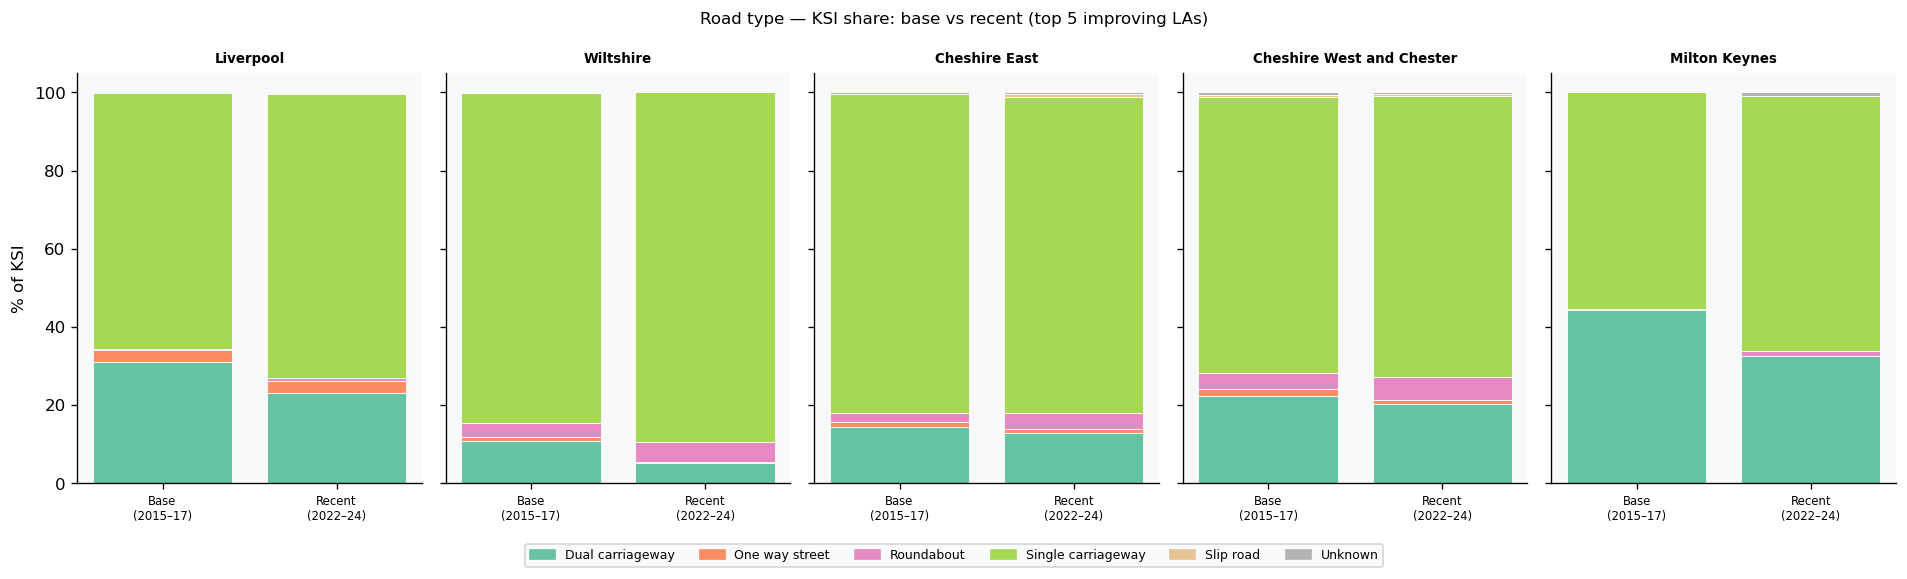

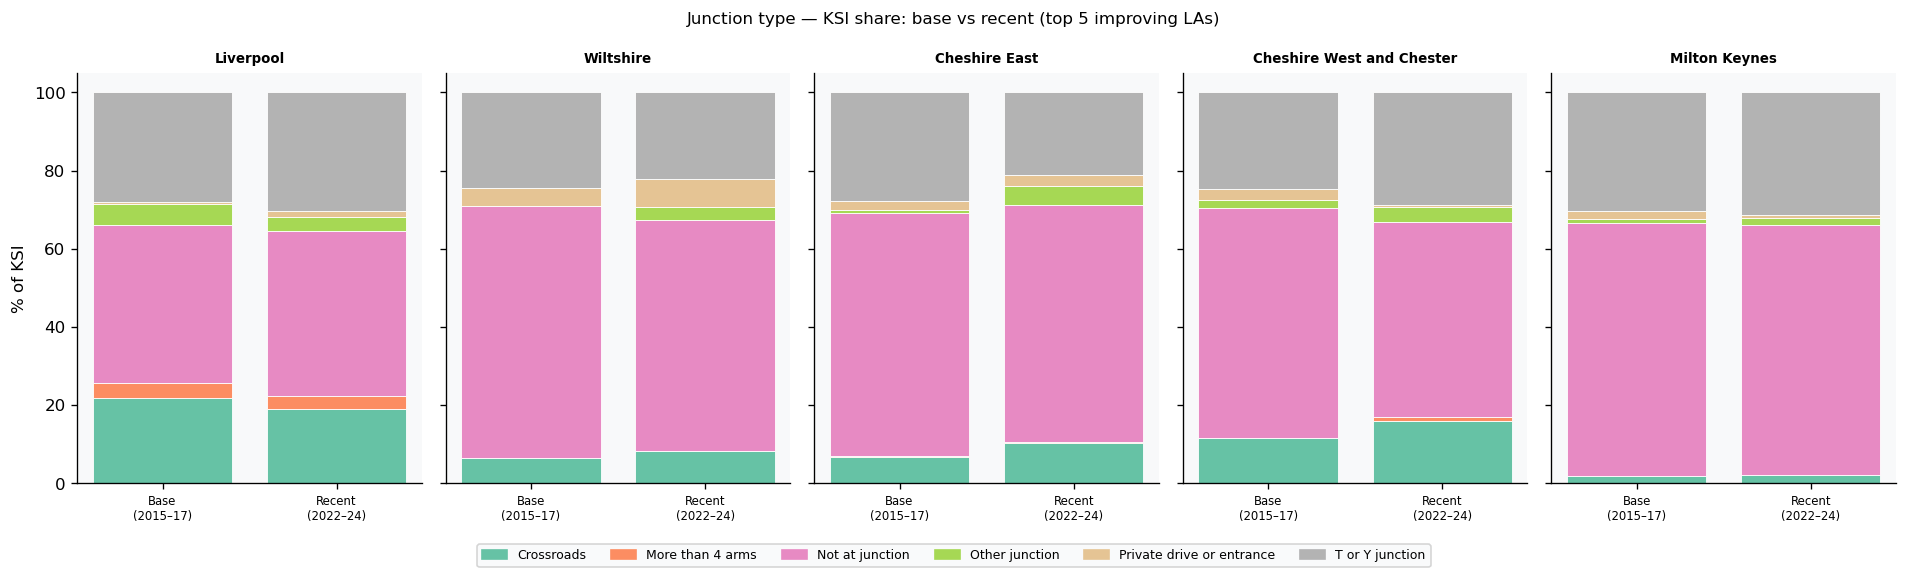

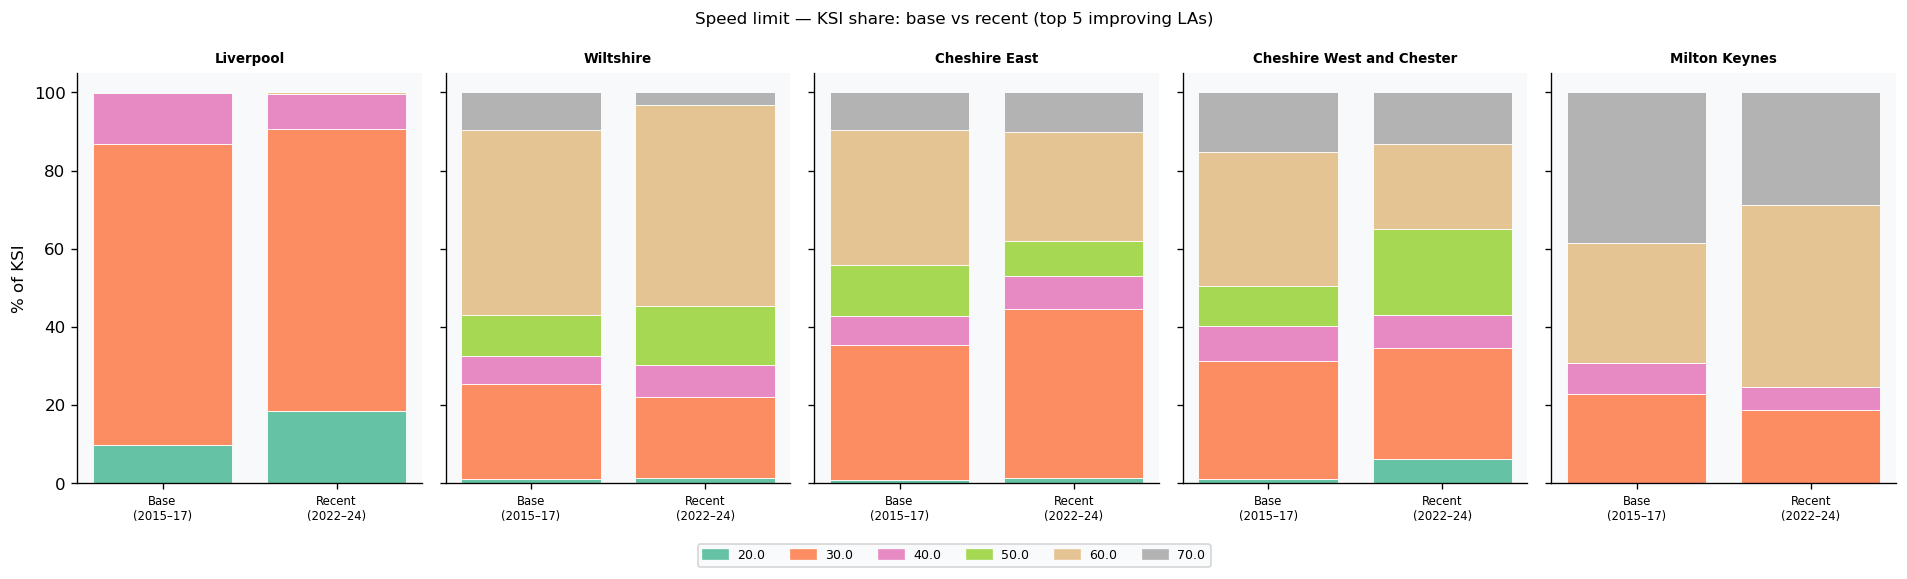

In [14]:
# Factor breakdown — KSI share base vs recent, top 5 improving LAs

deep_i = ksi_complete[
    ksi_complete['la_name'].isin(top5_i_names) &
    ksi_complete['collision_year'].isin(BASE_YEARS + RECENT_YEARS)
].copy()
deep_i['window'] = deep_i['collision_year'].apply(
    lambda y: 'Base\n(2015–17)' if y in BASE_YEARS else 'Recent\n(2022–24)'
)

for col, label in FACTORS:
    if col not in deep_i.columns:
        continue
    grp = (
        deep_i[deep_i[col].notna()]
        .groupby(['la_name', 'window', col]).size().reset_index(name='KSI')
    )
    grp['pct'] = grp.groupby(['la_name', 'window'])['KSI'].transform(lambda x: x / x.sum() * 100)
    cats = sorted(grp[col].dropna().unique().astype(str))
    cmap = plt.cm.get_cmap('Set2', len(cats))
    cat_colors = {c: cmap(i) for i, c in enumerate(cats)}
    fig, axes = plt.subplots(1, TOP_N, figsize=(16, 4.5), sharey=True)
    fig.suptitle(f'{label} — KSI share: base vs recent (top 5 improving LAs)', fontsize=10)
    windows = ['Base\n(2015–17)', 'Recent\n(2022–24)']
    for ax, la in zip(axes, top5_i_names):
        sub     = grp[grp['la_name'] == la]
        bottoms = [0, 0]
        for cat in cats:
            vals = []
            for w in windows:
                row = sub[(sub['window'] == w) & (sub[col].astype(str) == cat)]
                vals.append(row['pct'].values[0] if not row.empty else 0)
            ax.bar(windows, vals, bottom=bottoms, color=cat_colors[cat], edgecolor='white', lw=0.5)
            bottoms = [b + v for b, v in zip(bottoms, vals)]
        ax.set_title(la, fontsize=8, fontweight='bold')
        ax.set_ylim(0, 105)
        ax.tick_params(axis='x', labelsize=7)
        if ax == axes[0]: ax.set_ylabel('% of KSI')
    handles = [plt.Rectangle((0,0),1,1, color=cat_colors[c]) for c in cats]
    fig.legend(handles, cats, loc='lower center', ncol=min(len(cats), 7),
               fontsize=7.5, bbox_to_anchor=(0.5, -0.06))
    plt.tight_layout()
    plt.show()

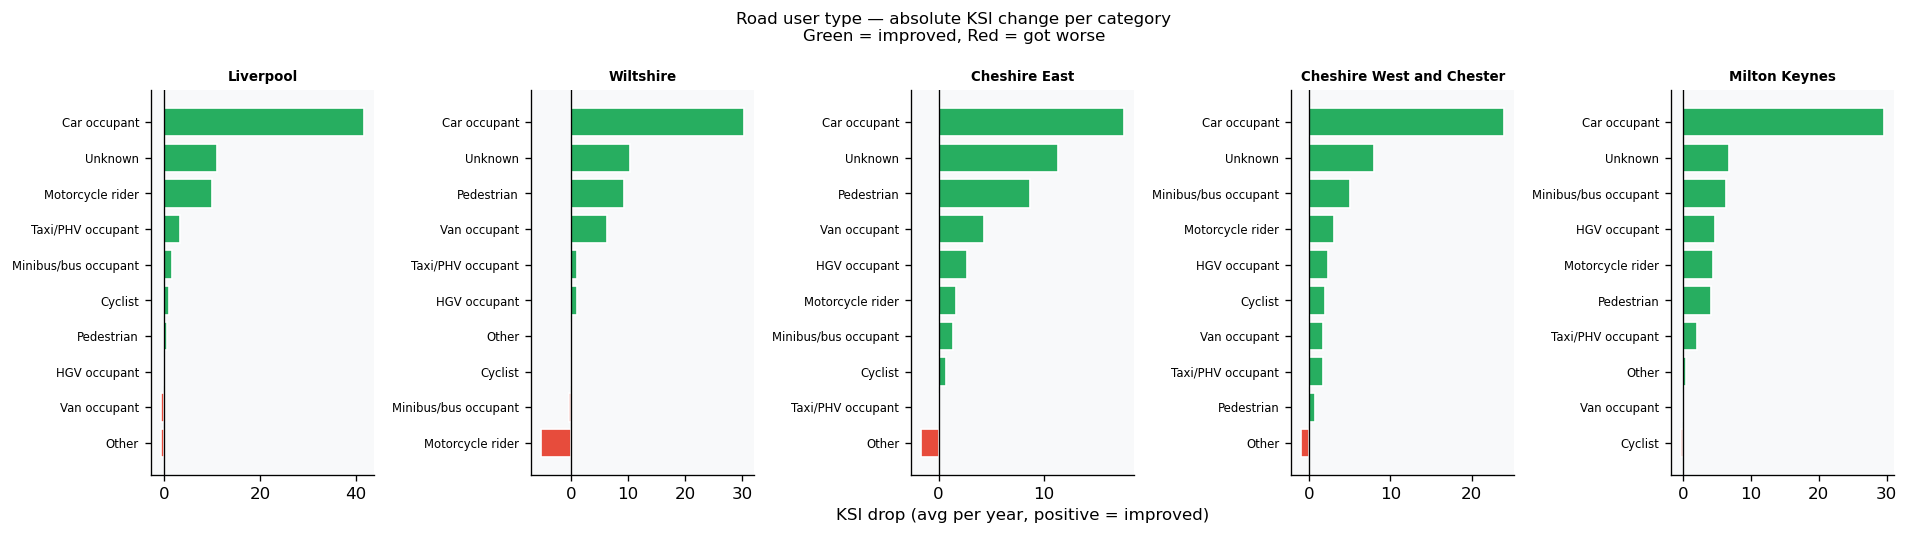

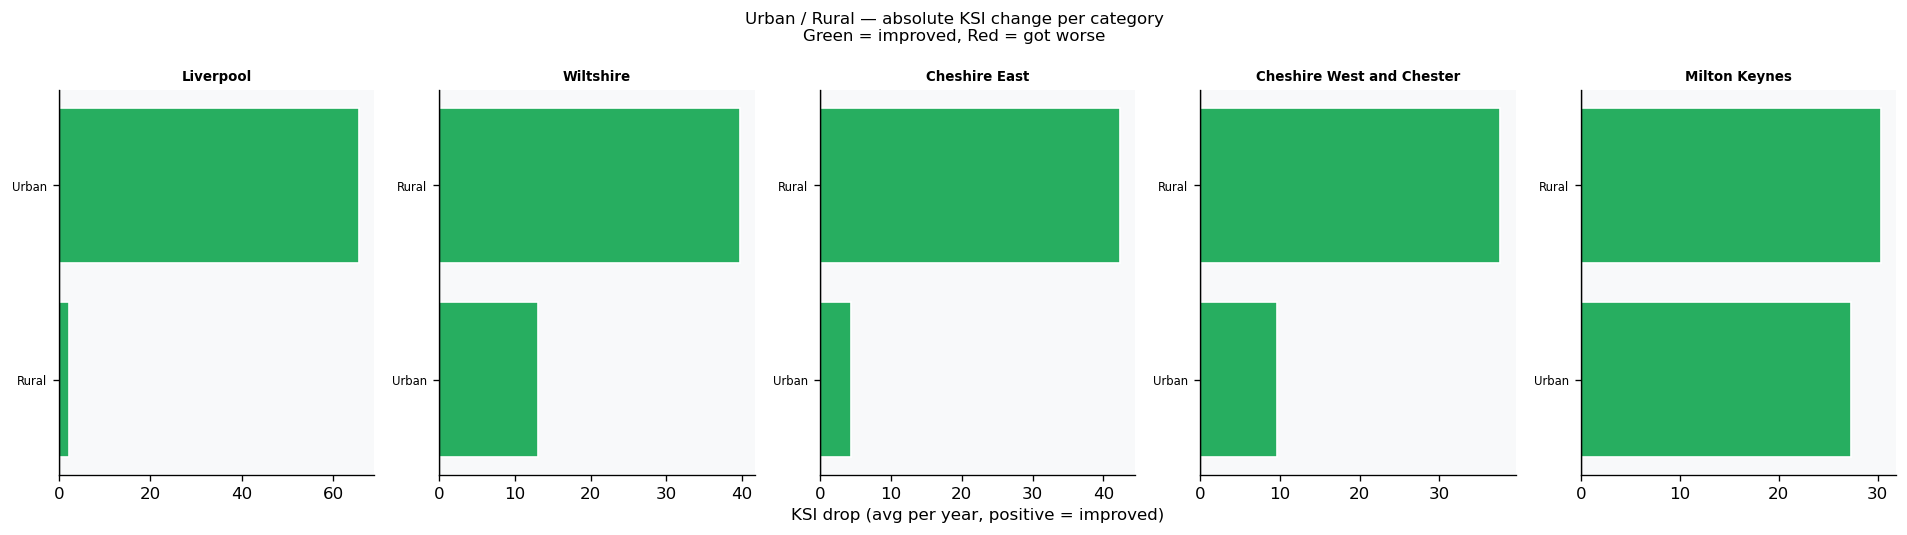

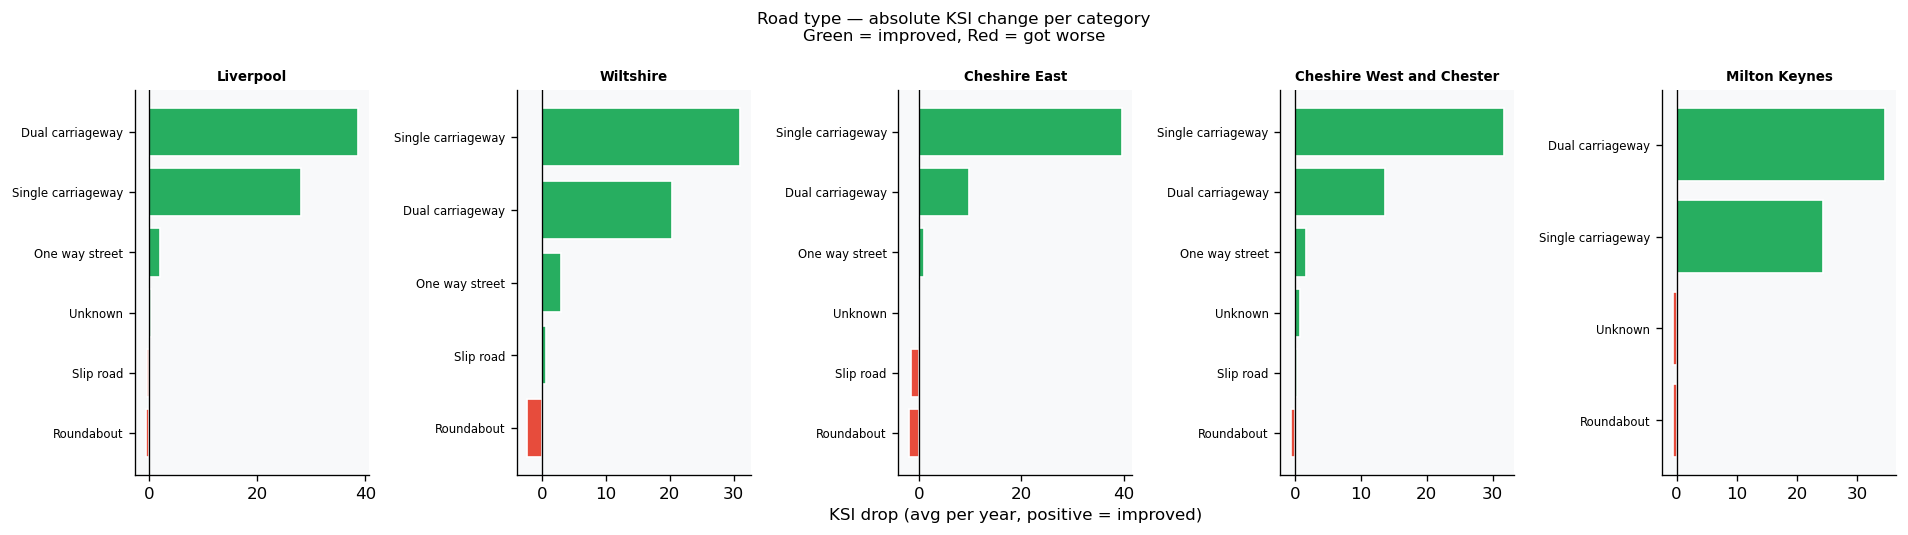

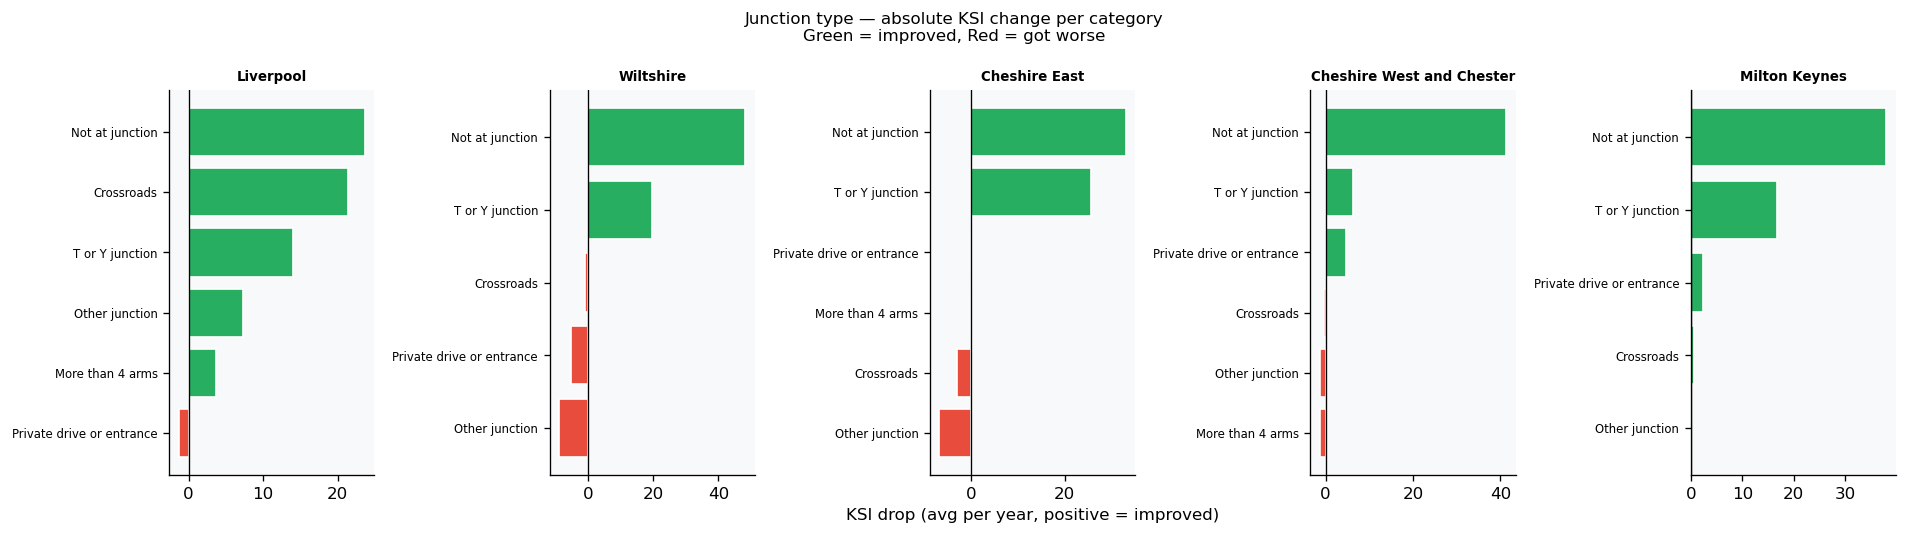

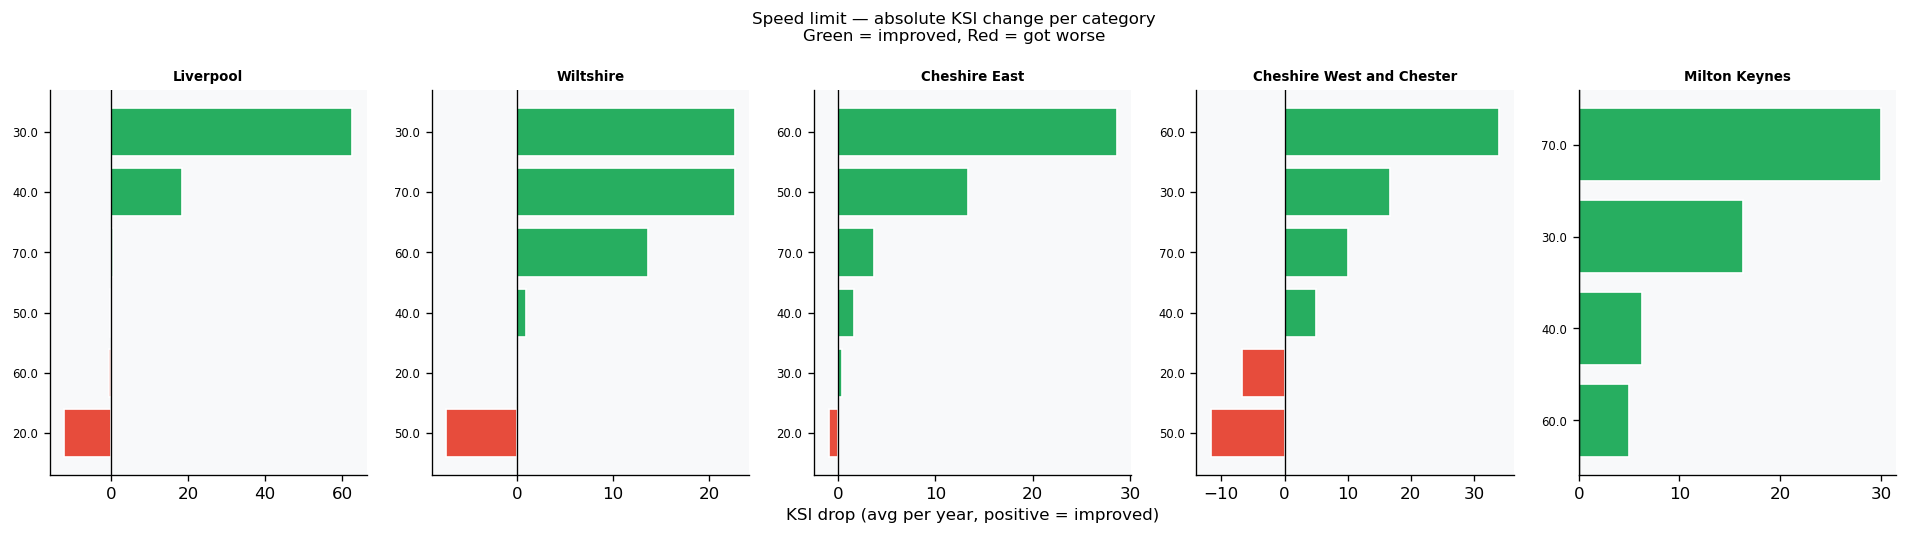

In [15]:
# Absolute KSI change per factor category — what drove the improvement?

for col, label in FACTORS:
    if col not in deep_i.columns:
        continue
    n_map = {'Base\n(2015–17)': len(BASE_YEARS), 'Recent\n(2022–24)': len(RECENT_YEARS)}
    grp = (
        deep_i[deep_i[col].notna()]
        .groupby(['la_name', 'window', col]).size().reset_index(name='ksi_count')
    )
    grp['ksi_avg'] = grp['ksi_count'] / grp['window'].map(n_map)
    pivot = grp.pivot_table(index=['la_name', col], columns='window',
                             values='ksi_avg', fill_value=0).reset_index()
    pivot.columns.name = None
    for w in ['Base\n(2015–17)', 'Recent\n(2022–24)']:
        if w not in pivot.columns: pivot[w] = 0
    pivot['drop'] = pivot['Base\n(2015–17)'] - pivot['Recent\n(2022–24)']
    fig, axes = plt.subplots(1, TOP_N, figsize=(16, 4.5), sharey=False)
    fig.suptitle(f'{label} — absolute KSI change per category\nGreen = improved, Red = got worse', fontsize=10)
    for ax, la in zip(axes, top5_i_names):
        sub    = pivot[pivot['la_name'] == la].sort_values('drop')
        colors = ['#27ae60' if v >= 0 else '#e74c3c' for v in sub['drop']]
        ax.barh(sub[col].astype(str), sub['drop'], color=colors, edgecolor='white')
        ax.axvline(0, color='black', lw=0.8)
        ax.set_title(la, fontsize=8, fontweight='bold')
        ax.tick_params(axis='y', labelsize=7)
        if ax == axes[2]: ax.set_xlabel('KSI drop (avg per year, positive = improved)')
    plt.tight_layout()
    plt.show()

---
## 5. Findings and Recommendations

**Bradford: focus on open roads, not junctions.** Bradford has the most consistent worsening trend in the dataset. Casualties are concentrated on open road sections — not at junctions. Pedestrians and car occupants are both affected. The priority is speed management and enforcement on urban through-roads. A site audit of the highest-casualty road sections is the practical next step.

**Southwark and Lambeth: fix junctions and enforce 20mph.** Both boroughs show growing casualties at T and Y junctions — junction upgrades are the most targeted response. In Southwark, 20mph limits have been introduced but casualties on those roads are still rising. Compliance and enforcement need to be reviewed alongside any engineering work.

**Highland: rural roads need a different approach.** Highland's problem is structural — high-speed single carriageway roads in a large rural area. Urban tools do not apply here. Road geometry, overtaking provision, and enforcement on the highest-risk A-road corridors are the relevant levers.

**Learn from Liverpool.** Liverpool has reduced KSI casualties consistently for ten years while introducing 20mph zones — casualties on those roads are falling. Southwark has introduced 20mph limits but casualties are rising. The policy is the same; the implementation and enforcement are likely different. A direct comparison of how Liverpool rolled out and enforced its 20mph programme would be a concrete and actionable next step.

**Use Milton Keynes as a benchmark.** Milton Keynes has achieved broad consistent improvement with no single obvious intervention. Authorities looking to improve overall performance rather than target a specific problem should examine what Milton Keynes has done across its network.

**Watch Leeds, but hold off on structural action.** Leeds jumped sharply after COVID and has stayed elevated. It warrants close monitoring — if 2025 data shows casualties staying at the 2022 level or above, structural intervention becomes urgent. If they start falling back toward pre-pandemic levels, the picture is different.

---
## 6. Methodological Notes

**Primary metric.** All analysis uses KSI casualties — individuals killed or seriously injured — not collision counts. One collision with three serious casualties contributes three to the analysis. Raw KSI counts are used rather than IBRS-adjusted figures. The IBRS adjustment is modelled at police force level, and applying it at local authority level (with multiple authorities per force) introduces additional uncertainty. For the final deliverable, IBRS sensitivity should be assessed. Separately, this analysis ranks by absolute casualty count rather than rate per population or per vehicle kilometre; a rate-based analysis would surface different authorities and the appropriate metric will be confirmed with the client.

**Completeness filter.** 53 authorities were excluded due to boundary reorganisations mid-window. The most significant is the April 2023 North Yorkshire restructuring. Without this filter, dissolved authorities produce spurious improvement signals — Harrogate showed an apparent 86% KSI drop, driven entirely by zero records in 2023–24 under the old name.

**OLS model.** A separate OLS regression of annual KSI count on year was fitted per authority using 2014–2024. COVID created a structural dip in 2020–21 that reduces R² across almost all authorities regardless of underlying trend direction. An R² threshold of 0.5 was used to distinguish sustained linear trends from spike or V-shape patterns. The slope is the primary ranking metric; R², p-value, and 3-year average comparison are used as supporting evidence. The 3-year average method (2015–17 vs 2022–24) agreed with the OLS direction for 88% of authorities.

**Factor breakdowns.** Comparisons of KSI share by factor category between base and recent windows are descriptive. Changes in speed limit distributions may reflect policy reclassification (20mph rollouts) rather than genuine shifts in collision location. This is particularly relevant for London boroughs and should be stated explicitly when presenting speed limit findings to the client.